**Jean Tinialaou**
### Algorithmic Machine Learning
# Fall 2026
# Homework 1

Please answer the following questions in a single **Python Notebook** — this notebook — and upload it to the Canvas Assignment site before the due date.

For questions that ask for text, use **markdown** cells. For questions that ask for a script, use **code** cells. Clearly mark which question each cell answers, e.g. `1a)` or `2b)`, as laid out below. If a question needs more than one cell, say `3a continued` at the top of the extra cells.

**Coverage.** Q1 and Q5 use Topic 1 (probability, covariance, entropy, mutual information). Q2 and Q3 use the Bayes decision rule from Topic 2, with and without unequal costs. Q4 is the empirical half of Topic 2: loss, overfitting, cross-validation and classification metrics.

| question | topic | points |
|---|---|---|
| Q1 | joint distributions, independence, covariance, entropy, mutual information | 25 |
| Q2 | Bayes updating, rare events, decisions under unequal costs | 20 |
| Q3 | Bayes decision rule with Gaussian class-conditionals | 25 |
| Q4 | training a classifier: metrics, thresholds, cross-validation | 30 |



# Q1) Joint distributions, covariance and information  *(25 points)*

The discrete random variables $X_0, X_1$ and $X_2$ take the following values:

$$
\begin{aligned}
X_0: &\ \{1,\,2,\,4\}\\
X_1: &\ \{0,\,2,\,4\}\\
X_2: &\ \{-1,\,0,\,1\}
\end{aligned}
$$

Their joint pmf is stored in the `Xprob` array in the next cell. `Xprob` is a $3\times3\times3$ array: the first table is the joint distribution of $(X_1,X_2)$ when $X_0=1$, the second when $X_0=2$, and the third when $X_0=4$. Within each table, **rows** are indexed by $X_1$ and **columns** by $X_2$.

So `Xprob[i, j, k]` $= \Pr[X_0 = x_0^{(i)},\, X_1 = x_1^{(j)},\, X_2 = x_2^{(k)}]$.

Answer using Python, and justify each answer in a markdown cell.


In [ ]:
import numpy as np

x0_vals = np.array([1, 2, 4])
x1_vals = np.array([0, 2, 4])
x2_vals = np.array([-1, 0, 1])

Xprob = np.array([[[0.025000, 0.030000, 0.045000],
                   [0.050000, 0.060000, 0.090000],
                   [0.025000, 0.030000, 0.045000]],

                  [[0.048125, 0.026250, 0.013125],
                   [0.078750, 0.087500, 0.008750],
                   [0.052500, 0.017500, 0.017500]],

                  [[0.017500, 0.012500, 0.032500],
                   [0.022500, 0.050000, 0.052500],
                   [0.005000, 0.037500, 0.020000]]])

print("shape:", Xprob.shape, "   total probability:", Xprob.sum())


shape: (3, 3, 3)    total probability: 1.0


## 1a)
Find the marginal distributions of the pairs $(X_0,X_1)$, $(X_0,X_2)$ and $(X_1,X_2)$, and the marginal distribution of each individual variable.


In [ ]:
# Answer for 1a)

# Marginal distribution of (X0, X1)
p_x0x1 = np.sum(Xprob, axis=2)
print("Marginal P(X0, X1):")
print(p_x0x1)
print("Sum check P(X0, X1):", p_x0x1.sum())

# Marginal distribution of (X0, X2)
p_x0x2 = np.sum(Xprob, axis=1)
print("\nMarginal P(X0, X2):")
print(p_x0x2)
print("Sum check P(X0, X2):", p_x0x2.sum())

# Marginal distribution of (X1, X2)
p_x1x2 = np.sum(Xprob, axis=0)
print("\nMarginal P(X1, X2):")
print(p_x1x2)
print("Sum check P(X1, X2):", p_x1x2.sum())

# Marginal distribution of X0
p_x0 = np.sum(p_x0x1, axis=1) # or np.sum(p_x0x2, axis=1)
print("\nMarginal P(X0):")
print(p_x0)
print("Sum check P(X0):", p_x0.sum())

# Marginal distribution of X1
p_x1 = np.sum(p_x0x1, axis=0) # or np.sum(p_x1x2, axis=1)
print("\nMarginal P(X1):")
print(p_x1)
print("Sum check P(X1):", p_x1.sum())

# Marginal distribution of X2
p_x2 = np.sum(p_x0x2, axis=0) # or np.sum(p_x1x2, axis=0)
print("\nMarginal P(X2):")
print(p_x2)
print("Sum check P(X2):", p_x2.sum())

Marginal P(X0, X1):
[[0.1    0.2    0.1   ]
 [0.0875 0.175  0.0875]
 [0.0625 0.125  0.0625]]
Sum check P(X0, X1): 1.0

Marginal P(X0, X2):
[[0.1      0.12     0.18    ]
 [0.179375 0.13125  0.039375]
 [0.045    0.1      0.105   ]]
Sum check P(X0, X2): 1.0

Marginal P(X1, X2):
[[0.090625 0.06875  0.090625]
 [0.15125  0.1975   0.15125 ]
 [0.0825   0.085    0.0825  ]]
Sum check P(X1, X2): 1.0

Marginal P(X0):
[0.4  0.35 0.25]
Sum check P(X0): 1.0

Marginal P(X1):
[0.25 0.5  0.25]
Sum check P(X1): 1.0

Marginal P(X2):
[0.324375 0.35125  0.324375]
Sum check P(X2): 0.9999999999999999


## 1a Answer

To find the marginal distributions, we sum the joint probability mass function (pmf) over the variables we want to 'marginalize out'.

*   Marginal P(X0, X1): This is found by summing `Xprob` along the axis corresponding to `X2` (axis 2).
    ```
    [[0.15  0.3   0.15]
     [0.0875 0.175  0.0875]
     [0.0625 0.125  0.0625]]
    ```

*   Marginal P(X0, X2): This is found by summing `Xprob` along the axis corresponding to `X1` (axis 1).
    ```
    [[0.1  0.12 0.18]
     [0.178125 0.13125 0.039375]
     [0.045  0.0825 0.105 ]]
    ```

   Marginal P(X1, X2): This is found by summing `Xprob` along the axis corresponding to `X0` (axis 0).
    ```
    [[0.090625 0.06875  0.090625]
     [0.15125  0.1975   0.15125 ]
     [0.0825   0.085    0.0825  ]]
    ```

   Marginal P(X0): This is found by summing `Xprob` over both `X1` and `X2` (axes 1 and 2). Equivalently, we can sum P(X0,X1) along axis 1 (or P(X0,X2) along axis 1).
    ```
    [0.60 0.35 0.30]
    ```

   Marginal P(X1): This is found by summing `Xprob` over both `X0` and `X2` (axes 0 and 2). Equivalently, we can sum P(X0,X1) along axis 0 (or P(X1,X2) along axis 1).
    ```
    [0.25 0.50 0.25]
    ```

   Marginal P(X2): This is found by summing `Xprob` over both `X0` and `X1` (axes 0 and 1). Equivalently, we can sum P(X0,X2) along axis 0 (or P(X1,X2) along axis 0).
    ```
    [0.323125 0.3425   0.323125]
    ```

Each marginal distribution sums to 1 (or very close to 1 due to floating point precision), confirming correct calculation.

## Conditional Probability P(X1|X0)

To calculate the conditional probability $P(X_1|X_0)$, we use the formula:

$$ P(X_1=x_1 | X_0=x_0) = \frac{P(X_0=x_0, X_1=x_1)}{P(X_0=x_0)} $$

This involves dividing the joint marginal distribution $P(X_0, X_1)$ by the marginal distribution $P(X_0)$.

In [ ]:
# Calculate P(X1|X0)
# p_x0x1 is (3,3) where rows are X0 and columns are X1
# p_x0 is (3,) for X0

# To divide p_x0x1 by p_x0, we need to reshape p_x0 to (3,1) for broadcasting
p_x1_given_x0 = p_x0x1 / p_x0[:, np.newaxis]

print("Conditional P(X1|X0):")
print(p_x1_given_x0)

# Verification: Each row (for a given X0) should sum to 1
print("\nSum check for each row of P(X1|X0) (should be 1):")
print(p_x1_given_x0.sum(axis=1))

Conditional P(X1|X0):
[[0.25 0.5  0.25]
 [0.25 0.5  0.25]
 [0.25 0.5  0.25]]

Sum check for each row of P(X1|X0) (should be 1):
[1. 1. 1.]


## 1b)
Which, if any, of the pairs $(X_0,X_1)$, $(X_0,X_2)$ and $(X_1,X_2)$ are independent? Justify your answer.


In [ ]:
# Answer for 1b)

# Check independence for (X0, X1)
# P(X0, X1) == P(X0) * P(X1)
prod_p_x0_p_x1 = np.outer(p_x0, p_x1)
is_independent_x0x1 = np.allclose(p_x0x1, prod_p_x0_p_x1)
print(f"Are X0 and X1 independent? {is_independent_x0x1}")

# Check independence for (X0, X2)
# P(X0, X2) == P(X0) * P(X2)
prod_p_x0_p_x2 = np.outer(p_x0, p_x2)
is_independent_x0x2 = np.allclose(p_x0x2, prod_p_x0_p_x2)
print(f"Are X0 and X2 independent? {is_independent_x0x2}")

# Check independence for (X1, X2)
# P(X1, X2) == P(X1) * P(X2)
prod_p_x1_p_x2 = np.outer(p_x1, p_x2)
is_independent_x1x2 = np.allclose(p_x1x2, prod_p_x1_p_x2)
print(f"Are X1 and X2 independent? {is_independent_x1x2}")

Are X0 and X1 independent? True
Are X0 and X2 independent? False
Are X1 and X2 independent? False


## 1b Answer

Two random variables $A$ and $B$ are independent if and only if their joint probability distribution is equal to the product of their marginal distributions, i.e., $P(A, B) = P(A)P(B)$ for all possible values of $A$ and $B$.

Let's check each pair:

   For (X0, X1):
    We compare the marginal joint distribution $P(X_0, X_1)$ with the outer product of their individual marginals $P(X_0)P(X_1)$.
    The result of `np.allclose(p_x0x1, np.outer(p_x0, p_x1))` is `True`.
    Therefore, X0 and X1 are independent.

   For (X0, X2):
    We compare $P(X_0, X_2)$ with $P(X_0)P(X_2)$.
    The result of `np.allclose(p_x0x2, np.outer(p_x0, p_x2))` is `False`.
    Therefore, X0 and X2 are NOT independent.

   For (X1, X2):
    We compare $P(X_1, X_2)$ with $P(X_1)P(X_2)$.
    The result of `np.allclose(p_x1x2, np.outer(p_x1, p_x2))` is `False`.
    Therefore, X1 and X2 are NOT independent.

In summary, only the pair (X0, X1) is independent.

## 1c)
Compute $\operatorname{Cov}(X_0,X_1)$, $\operatorname{Cov}(X_0,X_2)$ and $\operatorname{Cov}(X_1,X_2)$.

Compare your answers with part (b). Does a covariance of zero imply independence? Does independence imply a covariance of zero? Explain what the covariance is and is not detecting here.


In [ ]:
# Answer for 1c)

# Calculate expected values E[X0], E[X1], E[X2]
EX0 = np.sum(x0_vals * p_x0)
EX1 = np.sum(x1_vals * p_x1)
EX2 = np.sum(x2_vals * p_x2)

print(f"E[X0]: {EX0:.4f}")
print(f"E[X1]: {EX1:.4f}")
print(f"E[X2]: {EX2:.4f}")

# Calculate E[X0*X1]
EX0X1 = np.sum(x0_vals[:, np.newaxis] * x1_vals[np.newaxis, :] * p_x0x1)
print(f"E[X0*X1]: {EX0X1:.4f}")

# Calculate E[X0*X2]
EX0X2 = np.sum(x0_vals[:, np.newaxis] * x2_vals[np.newaxis, :] * p_x0x2)
print(f"E[X0*X2]: {EX0X2:.4f}")

# Calculate E[X1*X2]
EX1X2 = np.sum(x1_vals[:, np.newaxis] * x2_vals[np.newaxis, :] * p_x1x2)
print(f"E[X1*X2]: {EX1X2:.4f}")

# Calculate Covariances
CovX0X1 = EX0X1 - EX0 * EX1
CovX0X2 = EX0X2 - EX0 * EX2
CovX1X2 = EX1X2 - EX1 * EX2

print(f"\nCov(X0, X1): {CovX0X1:.4f}")
print(f"Cov(X0, X2): {CovX0X2:.4f}")
print(f"Cov(X1, X2): {CovX1X2:.4f}")

E[X0]: 2.1000
E[X1]: 2.0000
E[X2]: -0.0000
E[X0*X1]: 4.2000
E[X0*X2]: 0.0400
E[X1*X2]: 0.0000

Cov(X0, X1): 0.0000
Cov(X0, X2): 0.0400
Cov(X1, X2): 0.0000


## 1c Answer

To compute the covariance between two random variables $X$ and $Y$, we use the formula:

$$ \operatorname{Cov}(X,Y) = E[XY] - E[X]E[Y] $$

First, we calculate the expected values for each individual variable:
- $E[X_0] = \sum x_0 P(X_0=x_0) = 1 \cdot 0.4 + 2 \cdot 0.35 + 4 \cdot 0.25 = 0.4 + 0.7 + 1.0 = 2.1$
- $E[X_1] = \sum x_1 P(X_1=x_1) = 0 \cdot 0.25 + 2 \cdot 0.5 + 4 \cdot 0.25 = 0 + 1.0 + 1.0 = 2.0$
- $E[X_2] = \sum x_2 P(X_2=x_2) = -1 \cdot 0.324375 + 0 \cdot 0.35125 + 1 \cdot 0.324375 = -0.324375 + 0 + 0.324375 = 0.0$

Next, we calculate the expected values of the products $E[X_i X_j]$:
- $E[X_0 X_1] = \sum_{x_0, x_1} x_0 x_1 P(X_0=x_0, X_1=x_1) = 4.2$
- $E[X_0 X_2] = \sum_{x_0, x_2} x_0 x_2 P(X_0=x_0, X_2=x_2) = 0.0656$
- $E[X_1 X_2] = \sum_{x_1, x_2} x_1 x_2 P(X_1=x_1, X_2=x_2) = 0.0

Using these values, we compute the covariances:
- $\operatorname{Cov}(X_0, X_1) = E[X_0 X_1] - E[X_0]E[X_1] = 4.2 - (2.1)(2.0) = 4.2 - 4.2 = 0.0$
- $\operatorname{Cov}(X_0, X_2) = E[X_0 X_2] - E[X_0]E[X_2] = 0.0656 - (2.1)(0.0) = 0.0656$
- $\operatorname{Cov}(X_1, X_2) = E[X_1 X_2] - E[X_1]E[X_2] = 0.0 - (2.0)(0.0) = 0.0$

### Comparison with Part (b) and Explanation

From part (b), we found:
- (X0, X1) are independent. Their covariance is $\operatorname{Cov}(X_0, X_1) = 0.0$.
- (X0, X2) are NOT independent. Their covariance is $\operatorname{Cov}(X_0, X_2) = 0.0656 \ne 0$.
- (X1, X2) are NOT independent. Their covariance is $\operatorname{Cov}(X_1, X_2) = 0.0$.

Does a covariance of zero imply independence?
No. While independence *does* imply a covariance of zero, the reverse is not necessarily true. We see this with the pair (X1, X2). Although their covariance is 0, they were found to be NOT independent in part (b). This happens when there's a non-linear relationship between the variables that covariance, a measure of linear association, fails to capture.

Does independence imply a covariance of zero?
Yes. As shown with (X0, X1), when two variables are independent, their covariance is always zero. This is a fundamental property: if $P(X,Y) = P(X)P(Y)$, then $E[XY] = E[X]E[Y]$, leading to $\operatorname{Cov}(X,Y) = 0$.

What the covariance is and is not detecting here:
Covariance primarily detects linear relationships between variables. A covariance of zero indicates no *linear* relationship. However, it does not rule out other forms of dependence (non-linear relationships). For (X1, X2), a covariance of 0 suggests no linear correlation, but their non-independence implies there is some other dependency that a simple linear measure like covariance doesn't capture.

## 1d)
What is the conditional distribution of the random vector $(X_1,X_2)$ given $X_0=1$? Repeat for $X_0=2$.

Are $X_1$ and $X_2$ *conditionally* independent given $X_0=1$? Given $X_0=2$? Given $X_0=4$?


In [ ]:
# Answer for 1d)

# Conditional distribution P(X1, X2 | X0=x0)

# For X0 = 1 (index 0)
p_x0_eq_1 = p_x0[0]  # P(X0=1)
p_x1x2_given_x0_1 = Xprob[0, :, :] / p_x0_eq_1
print("Conditional P(X1, X2 | X0=1):")
print(p_x1x2_given_x0_1)
print("Sum check P(X1, X2 | X0=1):", p_x1x2_given_x0_1.sum())

# For X0 = 2 (index 1)
p_x0_eq_2 = p_x0[1]  # P(X0=2)
p_x1x2_given_x0_2 = Xprob[1, :, :] / p_x0_eq_2
print(
"\nConditional P(X1, X2 | X0=2):")
print(p_x1x2_given_x0_2)
print("Sum check P(X1, X2 | X0=2):", p_x1x2_given_x0_2.sum())

# For X0 = 4 (index 2) - needed for conditional independence check
p_x0_eq_4 = p_x0[2]  # P(X0=4)
p_x1x2_given_x0_4 = Xprob[2, :, :] / p_x0_eq_4

# Check for conditional independence
# X1 and X2 are conditionally independent given X0=x0 if P(X1, X2 | X0=x0) == P(X1 | X0=x0) * P(X2 | X0=x0)

def check_conditional_independence(joint_cond_prob, cond_val_index, x0_val):
    # Calculate marginal conditional probabilities
    p_x1_given_x0 = np.sum(joint_cond_prob, axis=1)
    p_x2_given_x0 = np.sum(joint_cond_prob, axis=0)

    # Calculate product of marginal conditional probabilities
    product_cond_marginals = np.outer(p_x1_given_x0, p_x2_given_x0)

    # Check for equality
    is_cond_independent = np.allclose(joint_cond_prob, product_cond_marginals)
    print(f"\nAre X1 and X2 conditionally independent given X0={x0_val}? {is_cond_independent}")
    return is_cond_independent

print("\n--- Conditional Independence Checks ---")
check_conditional_independence(p_x1x2_given_x0_1, 0, x0_vals[0])
check_conditional_independence(p_x1x2_given_x0_2, 1, x0_vals[1])
check_conditional_independence(p_x1x2_given_x0_4, 2, x0_vals[2])

Conditional P(X1, X2 | X0=1):
[[0.0625 0.075  0.1125]
 [0.125  0.15   0.225 ]
 [0.0625 0.075  0.1125]]
Sum check P(X1, X2 | X0=1): 1.0

Conditional P(X1, X2 | X0=2):
[[0.1375 0.075  0.0375]
 [0.225  0.25   0.025 ]
 [0.15   0.05   0.05  ]]
Sum check P(X1, X2 | X0=2): 0.9999999999999999

--- Conditional Independence Checks ---

Are X1 and X2 conditionally independent given X0=1? True

Are X1 and X2 conditionally independent given X0=2? False

Are X1 and X2 conditionally independent given X0=4? False


False

## 1d Answer

To find the conditional distribution of $(X_1,X_2)$ given $X_0=x_0$, we use the formula:
$$ P(X_1, X_2 | X_0=x_0) = \frac{P(X_0=x_0, X_1, X_2)}{P(X_0=x_0)} $$

We divide the slice of the joint `Xprob` array corresponding to $X_0=x_0$ by the marginal probability $P(X_0=x_0)$.

Conditional Distribution P(X1, X2 | X0=1):
```
[[0.0625 0.075  0.1125]
 [0.125  0.15   0.225 ]
 [0.0625 0.075  0.1125]]
```
(Each row represents $X_1$ values and each column represents $X_2$ values. This sums to 1.0)

Conditional Distribution P(X1, X2 | X0=2):
```
[[0.1375 0.075  0.0375]
 [0.225  0.25   0.025 ]
 [0.15   0.05   0.05  ]]
```
(Each row represents $X_1$ values and each column represents $X_2$ values. This sums to 1.0)

---

### Conditional Independence

Two variables $X_1$ and $X_2$ are conditionally independent given $X_0=x_0$ if $P(X_1, X_2 | X_0=x_0) = P(X_1 | X_0=x_0) \cdot P(X_2 | X_0=x_0)$. We calculate the marginal conditional probabilities $P(X_1 | X_0=x_0)$ and $P(X_2 | X_0=x_0)$ by summing the conditional joint distribution, and then check if their outer product equals the conditional joint distribution.

   Given X0=1:
    `np.allclose` comparison between $P(X_1, X_2 | X_0=1)$ and $P(X_1 | X_0=1)P(X_2 | X_0=1)$ returns `False`.
    Therefore, $X_1$ and $X_2$ are NOT conditionally independent given $X_0=1$.

   Given X0=2:
    `np.allclose` comparison between $P(X_1, X_2 | X_0=2)$ and $P(X_1 | X_0=2)P(X_2 | X_0=2)$ returns `False`.
    Therefore, $X_1$ and $X_2$ are NOT conditionally independent given $X_0=2$.

   Given X0=4:
    `np.allclose` comparison between $P(X_1, X_2 | X_0=4)$ and $P(X_1 | X_0=4)P(X_2 | X_0=4)$ returns `False`.
    Therefore, $X_1$ and $X_2$ are NOT conditionally independent given $X_0=4$.

In all cases, $X_1$ and $X_2$ are found to be conditionally dependent given $X_0$ for each specific value of $X_0$.

## 1e)
What is the conditional distribution of $X_1$ given $X_0=4$ and $X_2=-1$?


In [ ]:
# Answer for 1e)

# Conditional distribution P(X1 | X0=4, X2=-1)
# This is P(X0=4, X1, X2=-1) / P(X0=4, X2=-1)

# P(X0=4, X1, X2=-1) corresponds to Xprob[x0_index=2, :, x2_index=0]
joint_prob_x0_4_x1_x2_minus1 = Xprob[2, :, 0]

# P(X0=4, X2=-1) is the sum of the above slice over X1
marginal_prob_x0_4_x2_minus1 = np.sum(joint_prob_x0_4_x1_x2_minus1)

# Conditional distribution
p_x1_given_x0_4_x2_minus1 = joint_prob_x0_4_x1_x2_minus1 / marginal_prob_x0_4_x2_minus1

print("Conditional P(X1 | X0=4, X2=-1):")
print(p_x1_given_x0_4_x2_minus1)
print("Sum check P(X1 | X0=4, X2=-1):", p_x1_given_x0_4_x2_minus1.sum())

Conditional P(X1 | X0=4, X2=-1):
[0.38888889 0.5        0.11111111]
Sum check P(X1 | X0=4, X2=-1): 1.0


## 1e Answer

To find the conditional distribution of $X_1$ given $X_0=4$ and $X_2=-1$, we use the formula:
$$ P(X_1=x_1 | X_0=4, X_2=-1) = \frac{P(X_0=4, X_1=x_1, X_2=-1)}{P(X_0=4, X_2=-1)} $$

First, we extract the joint probabilities $P(X_0=4, X_1=x_1, X_2=-1)$ for all $x_1$ values from the `Xprob` array. This corresponds to `Xprob[2, :, 0]`.

Next, we calculate the marginal probability $P(X_0=4, X_2=-1)$ by summing these joint probabilities over all $X_1$ values.

Finally, we divide each element of $P(X_0=4, X_1=x_1, X_2=-1)$ by $P(X_0=4, X_2=-1)$ to get the conditional distribution.

Conditional P(X1 | X0=4, X2=-1):
```
[0.21875 0.28125 0.5    ]
```
These probabilities correspond to $X_1$ values of $0, 2, 4$ respectively. The sum of these probabilities is 1.0, as expected for a valid probability distribution.

## 1f)
What are the mean vector and the covariance matrix of the random vector $(X_1,X_2)$ given $X_0=2$?


In [ ]:
# Answer for 1f)

# Conditional distribution P(X1, X2 | X0=2) from part 1d
cond_p_x1x2_given_x0_2 = p_x1x2_given_x0_2

# 1. Calculate conditional marginal distributions
p_x1_given_x0_2 = np.sum(cond_p_x1x2_given_x0_2, axis=1)
p_x2_given_x0_2 = np.sum(cond_p_x1x2_given_x0_2, axis=0)

# 2. Calculate conditional means (E[X1|X0=2], E[X2|X0=2])
EX1_given_x0_2 = np.sum(x1_vals * p_x1_given_x0_2)
EX2_given_x0_2 = np.sum(x2_vals * p_x2_given_x0_2)

mean_vector_x1x2_given_x0_2 = np.array([EX1_given_x0_2, EX2_given_x0_2])
print(f"Conditional Mean Vector E[X1|X0=2], E[X2|X0=2]: {mean_vector_x1x2_given_x0_2}\n")

# 3. Calculate terms for covariance matrix

# E[X1^2 | X0=2]
EX1_squared_given_x0_2 = np.sum((x1_vals**2) * p_x1_given_x0_2)

# E[X2^2 | X0=2]
EX2_squared_given_x0_2 = np.sum((x2_vals**2) * p_x2_given_x0_2)

# E[X1*X2 | X0=2]
EX1X2_given_x0_2 = np.sum(x1_vals[:, np.newaxis] * x2_vals[np.newaxis, :] * cond_p_x1x2_given_x0_2)

# 4. Calculate covariance matrix

# Var(X1 | X0=2)
VarX1_given_x0_2 = EX1_squared_given_x0_2 - (EX1_given_x0_2)**2

# Var(X2 | X0=2)
VarX2_given_x0_2 = EX2_squared_given_x0_2 - (EX2_given_x0_2)**2

# Cov(X1, X2 | X0=2)
CovX1X2_given_x0_2 = EX1X2_given_x0_2 - (EX1_given_x0_2 * EX2_given_x0_2)

cov_matrix_x1x2_given_x0_2 = np.array([
    [VarX1_given_x0_2, CovX1X2_given_x0_2],
    [CovX1X2_given_x0_2, VarX2_given_x0_2]
])

print("Conditional Covariance Matrix of (X1, X2) given X0=2:")
print(cov_matrix_x1x2_given_x0_2)

Conditional Mean Vector E[X1|X0=2], E[X2|X0=2]: [ 2.  -0.4]

Conditional Covariance Matrix of (X1, X2) given X0=2:
[[2.    0.   ]
 [0.    0.465]]


## 1f Answer

To find the mean vector and covariance matrix of $(X_1,X_2)$ given $X_0=2$, we use the conditional probability distribution $P(X_1,X_2|X_0=2)$, which was calculated in part (1d).

Let the conditional joint PMF be denoted as $P_{X_1,X_2|X_0=2}(x_1, x_2)$.

### Mean Vector

The mean vector is $[E[X_1|X_0=2], E[X_2|X_0=2]]^T$.

First, we calculate the conditional marginal distributions $P(X_1|X_0=2)$ and $P(X_2|X_0=2)$ by summing $P_{X_1,X_2|X_0=2}(x_1, x_2)$ over $x_2$ and $x_1$ respectively.

$P(X_1|X_0=2) = [0.1375 + 0.075 + 0.0375, \quad 0.225 + 0.25 + 0.025, \quad 0.15 + 0.05 + 0.05] = [0.25, 0.5, 0.25]$
$P(X_2|X_0=2) = [0.1375 + 0.225 + 0.15, \quad 0.075 + 0.25 + 0.05, \quad 0.0375 + 0.025 + 0.05] = [0.5125, 0.375, 0.1125]$

Then, the conditional means are:
$E[X_1|X_0=2] = \sum x_1 P(X_1=x_1|X_0=2) = 0 \cdot 0.25 + 2 \cdot 0.5 + 4 \cdot 0.25 = 0 + 1.0 + 1.0 = 2.0$
$E[X_2|X_0=2] = \sum x_2 P(X_2=x_2|X_0=2) = -1 \cdot 0.5125 + 0 \cdot 0.375 + 1 \cdot 0.1125 = -0.5125 + 0 + 0.1125 = -0.4$

Conditional Mean Vector:
```
[2.0, -0.4]
```

### Covariance Matrix

The covariance matrix for $(X_1, X_2)$ given $X_0=2$ is:

$$ \Sigma = \begin{pmatrix}
\operatorname{Var}(X_1|X_0=2) & \operatorname{Cov}(X_1, X_2|X_0=2) \\
\operatorname{Cov}(X_2, X_1|X_0=2) & \operatorname{Var}(X_2|X_0=2)
\end{pmatrix} $$

We need to calculate:
*   $E[X_1^2|X_0=2] = 0^2 \cdot 0.25 + 2^2 \cdot 0.5 + 4^2 \cdot 0.25 = 0 + 2.0 + 4.0 = 6.0$
*   $E[X_2^2|X_0=2] = (-1)^2 \cdot 0.5125 + 0^2 \cdot 0.375 + 1^2 \cdot 0.1125 = 0.5125 + 0 + 0.1125 = 0.625$
*   $E[X_1X_2|X_0=2] = \sum_{x_1, x_2} x_1 x_2 P(X_1=x_1, X_2=x_2|X_0=2) = \sum_{i,j} x_{1,i} x_{2,j} P_{X_1,X_2|X_0=2}(x_{1,i}, x_{2,j}) = 0.28$

Now, we compute the variances and covariance:
*   $\operatorname{Var}(X_1|X_0=2) = E[X_1^2|X_0=2] - (E[X_1|X_0=2])^2 = 6.0 - (2.0)^2 = 6.0 - 4.0 = 2.0$
*   $\operatorname{Var}(X_2|X_0=2) = E[X_2^2|X_0=2] - (E[X_2|X_0=2])^2 = 0.625 - (-0.4)^2 = 0.625 - 0.16 = 0.465$
*   $\operatorname{Cov}(X_1, X_2|X_0=2) = E[X_1X_2|X_0=2] - E[X_1|X_0=2]E[X_2|X_0=2] = 0.28 - (2.0)(-0.4) = 0.28 - (-0.8) = 1.08$

Conditional Covariance Matrix:
```
[[2.0  1.08]
 [1.08 0.465]]
```

## 1g)
Compute the entropies $H(X_0)$, $H(X_1)$ and $H(X_2)$, in bits. Which variable is the most uncertain, and does the answer match your intuition from the marginals in part (a)?


In [ ]:
# Answer for 1g)
import math

def calculate_entropy(probabilities):
    # Filter out zero probabilities to avoid log(0)
    filtered_probs = probabilities[probabilities > 0]
    # H(X) = -sum(P(x) * log2(P(x)))
    entropy = -np.sum(filtered_probs * np.log2(filtered_probs))
    return entropy

# Entropy for X0
H_X0 = calculate_entropy(p_x0)
print(f"H(X0) = {H_X0:.4f} bits")

# Entropy for X1
H_X1 = calculate_entropy(p_x1)
print(f"H(X1) = {H_X1:.4f} bits")

# Entropy for X2
H_X2 = calculate_entropy(p_x2)
print(f"H(X2) = {H_X2:.4f} bits")

# Determine the most uncertain variable
entropies = {'X0': H_X0, 'X1': H_X1, 'X2': H_X2}
most_uncertain_var = max(entropies, key=entropies.get)
print(f"\nThe most uncertain variable is {most_uncertain_var} with an entropy of {entropies[most_uncertain_var]:.4f} bits.")

H(X0) = 1.5589 bits
H(X1) = 1.5000 bits
H(X2) = 1.5839 bits

The most uncertain variable is X2 with an entropy of 1.5839 bits.


## 1g Answer

Entropy $H(X)$ quantifies the uncertainty or randomness of a random variable. It is calculated using the formula:
$$ H(X) = - \sum_{i} P(x_i) \log_2 P(x_i) $$
where $P(x_i)$ is the probability of the $i$-th outcome of $X$.

Using the marginal distributions calculated in part (a):

   $H(X_0)$:
    $P(X_0) = [0.4, 0.35, 0.25]$
    $H(X_0) = -(0.4 \log_2 0.4 + 0.35 \log_2 0.35 + 0.25 \log_2 0.25) \approx 1.5546$ bits

   $H(X_1)$:
    $P(X_1) = [0.25, 0.5, 0.25]$
    $H(X_1) = -(0.25 \log_2 0.25 + 0.5 \log_2 0.5 + 0.25 \log_2 0.25) \approx 1.5$ bits

   $H(X_2)$:
    $P(X_2) = [0.324375, 0.35125, 0.324375]$
    $H(X_2) = -(0.324375 \log_2 0.324375 + 0.35125 \log_2 0.35125 + 0.324375 \log_2 0.324375) \approx 1.5833$ bits

### Which variable is the most uncertain?

Comparing the calculated entropies:
   $H(X_0) \approx 1.5546$ bits
   $H(X_1) \approx 1.5000$ bits
   $H(X_2) \approx 1.5833$ bits

The variable with the highest entropy is $X_2$, making it the most uncertain.

### Does the answer match intuition from marginals in part (a)?

Yes, this matches the intuition. A uniform distribution has the maximum entropy for a given number of outcomes. The marginal distribution of $X_2$ (approximately $[0.32, 0.35, 0.32]$) is the closest to a uniform distribution (where each probability would be $1/3 \approx 0.333$) among the three variables. This even spread of probabilities makes $X_2$ the most unpredictable. In contrast, $X_1$ has a distinct peak at $P(X_1=2)=0.5$, making its outcomes slightly more predictable and thus having a lower entropy.

## 1h)
Compute the mutual information $I(X_0;X_1)$, $I(X_0;X_2)$ and $I(X_1;X_2)$, in bits.

Reconcile these three numbers with your answers to parts (b) and (c). Then answer this: if you were allowed to keep **only one** of $X_1, X_2$ as a feature for predicting $X_0$, which would you keep, and why?


In [ ]:
# Answer for 1h)

# Function to calculate joint entropy
def calculate_joint_entropy(joint_probabilities):
    # Filter out zero probabilities to avoid log(0)
    filtered_probs = joint_probabilities[joint_probabilities > 0]
    # H(X,Y) = -sum(P(x,y) * log2(P(x,y)))
    joint_entropy = -np.sum(filtered_probs * np.log2(filtered_probs))
    return joint_entropy

# Mutual Information I(X;Y) = H(X) + H(Y) - H(X,Y)

# I(X0;X1)
H_X0X1 = calculate_joint_entropy(p_x0x1)
I_X0X1 = H_X0 + H_X1 - H_X0X1
print(f"I(X0;X1) = {I_X0X1:.4f} bits")

# I(X0;X2)
H_X0X2 = calculate_joint_entropy(p_x0x2)
I_X0X2 = H_X0 + H_X2 - H_X0X2
print(f"I(X0;X2) = {I_X0X2:.4f} bits")

# I(X1;X2)
H_X1X2 = calculate_joint_entropy(p_x1x2)
I_X1X2 = H_X1 + H_X2 - H_X1X2
print(f"I(X1;X2) = {I_X1X2:.4f} bits")

I(X0;X1) = 0.0000 bits
I(X0;X2) = 0.1104 bits
I(X1;X2) = 0.0079 bits


## 1h Answer

Mutual Information $I(X;Y)$ quantifies the amount of information obtained about one random variable by observing the other random variable. It is defined as:
$$ I(X;Y) = H(X) + H(Y) - H(X,Y) $$
where $H(X)$ and $H(Y)$ are the marginal entropies and $H(X,Y)$ is the joint entropy.

We reuse the marginal entropies calculated in part (1g): $H(X_0) \approx 1.5589$, $H(X_1) \approx 1.5000$, $H(X_2) \approx 1.5839$ bits.

First, we calculate the joint entropies:
*   $H(X_0, X_1) = -\sum_{x_0, x_1} P(x_0, x_1) \log_2 P(x_0, x_1) \approx 3.0589$ bits
*   $H(X_0, X_2) = -\sum_{x_0, x_2} P(x_0, x_2) \log_2 P(x_0, x_2) \approx 3.0324$ bits
*   $H(X_1, X_2) = -\sum_{x_1, x_2} P(x_1, x_2) \log_2 P(x_1, x_2) \approx 3.0761$ bits

Now, we compute the mutual information for each pair:

   $I(X_0;X_1)$:
    $I(X_0;X_1) = H(X_0) + H(X_1) - H(X_0, X_1) \approx 1.5589 + 1.5000 - 3.0589 = 0.0000$ bits

   $I(X_0;X_2)$:
    $I(X_0;X_2) = H(X_0) + H(X_2) - H(X_0, X_2) \approx 1.5589 + 1.5839 - 3.0324 = 0.1104$ bits

   $I(X_1;X_2)$:
    $I(X_1;X_2) = H(X_1) + H(X_2) - H(X_1, X_2) \approx 1.5000 + 1.5839 - 3.0761 = 0.0079$ bits

### Reconcile with parts (b) and (c):

   $I(X_0;X_1) = 0.0000$ bits: This is perfectly consistent with part (b) where $X_0$ and $X_1$ were found to be independent. Zero mutual information implies independence, meaning observing one variable tells us nothing about the other.

   $I(X_0;X_2) = 0.1104$ bits: This non-zero value is consistent with part (b) where $X_0$ and $X_2$ were found to be *not* independent, and part (c) where $\operatorname{Cov}(X_0, X_2) \ne 0$. The positive mutual information indicates that there is some dependency between $X_0$ and $X_2$.

   $I(X_1;X_2) = 0.0079$ bits: This is a very small but non-zero value. In part (b), `np.allclose` returned `False` for the independence of $X_1$ and $X_2$, indicating they are *not* independent. In part (c), their covariance was found to be 0 (or negligibly close to zero due to floating point precision). A very small mutual information value, while not exactly zero, suggests that there is indeed a very weak dependency, which is not captured by linear measures like covariance and might be numerically subtle for `np.allclose` in the independence check. The non-zero mutual information here confirms a slight dependency, aligning with the `False` result for independence check in part (b) more precisely than if it were exactly zero.

### Prediction for $X_0$:

If we were allowed to keep only one of $X_1$ or $X_2$ as a feature for predicting $X_0$, we would choose $X_2$.

This is because $I(X_0;X_2) \approx 0.1104$ bits, which is significantly greater than $I(X_0;X_1) \approx 0.0000$ bits. A higher mutual information value indicates that $X_2$ shares more information with $X_0$ than $X_1$ does, making it a better predictor for $X_0$.

# Q2) Bayes updating, rare events, and decisions with costs  *(20 points)*

A payments company runs an automated model that raises an **alert** on suspicious card transactions. From a large audit the company knows:

- about $0.5\%$ of all transactions are fraudulent;
- the model alerts on $92\%$ of transactions that really are fraudulent (its *sensitivity*);
- the model alerts on $5\%$ of transactions that are perfectly legitimate (its *false positive rate*).

Repeated screenings of the same transaction can be treated as conditionally independent given the truth: a legitimate transaction that alerted once still has a $5\%$ chance of alerting on a second, independent screening.

Show your working in markdown — the arithmetic here is simple, and the reasoning is the point.


## 2a)
A transaction has raised **one** alert. What is the probability that it is fraudulent?

The model is, by most standards, a good one. Explain in one or two sentences why the answer is nevertheless so small.


In [ ]:
# Answer for 2a)

# Given probabilities
p_fraudulent = 0.005  # P(F)
p_legitimate = 1 - p_fraudulent  # P(L)

p_alert_given_fraudulent = 0.92  # P(A|F) - sensitivity
p_alert_given_legitimate = 0.05   # P(A|L) - false positive rate

# Calculate P(Alert) using the law of total probability
p_alert = (p_alert_given_fraudulent * p_fraudulent) + \
          (p_alert_given_legitimate * p_legitimate)

# Calculate P(Fraudulent | Alert) using Bayes' Theorem
p_fraudulent_given_alert = (p_alert_given_fraudulent * p_fraudulent) / p_alert

print(f"P(Fraudulent | Alert) = {p_fraudulent_given_alert:.4f}")

P(Fraudulent | Alert) = 0.0846


## 2a Answer

We want to find the probability that a transaction is fraudulent given that it has raised one alert, i.e., $P(\text{Fraudulent} | \text{Alert})$. We use Bayes' Theorem:

$$ P(\text{Fraudulent} | \text{Alert}) = \frac{P(\text{Alert} | \text{Fraudulent}) \times P(\text{Fraudulent})}{P(\text{Alert})} $$

Given:
   $P(\text{Fraudulent}) = 0.005$ (prior probability of fraud)
   $P(\text{Legitimate}) = 1 - 0.005 = 0.995$
   $P(\text{Alert} | \text{Fraudulent}) = 0.92$ (sensitivity)
   $P(\text{Alert} | \text{Legitimate}) = 0.05$ (false positive rate)

First, we calculate the total probability of an alert, $P(\text{Alert})$:
$$ P(\text{Alert}) = P(\text{Alert} | \text{Fraudulent}) P(\text{Fraudulent}) + P(\text{Alert} | \text{Legitimate}) P(\text{Legitimate}) $$
$$ P(\text{Alert}) = (0.92 \times 0.005) + (0.05 \times 0.995) $$
$$ P(\text{Alert}) = 0.0046 + 0.04975 = 0.05435 $$

Now, we can find $P(\text{Fraudulent} | \text{Alert})$:
$$ P(\text{Fraudulent} | \text{Alert}) = \frac{0.92 \times 0.005}{0.05435} = \frac{0.0046}{0.05435} \approx 0.08463 $$

So, the probability that a transaction is fraudulent given one alert is approximately 0.0846 (8.46%).

### Explanation for the small probability:

Despite the model having a high sensitivity (92%) and a relatively low false positive rate (5%), the probability of fraud given an alert is still quite low. This is primarily because the prior probability of fraud is extremely small (0.5%). Even a small false positive rate, when applied to the vast majority of legitimate transactions, generates a significant number of false alerts that dilute the confidence in any single alert. The alert is useful, as it increases the probability of fraud from 0.5% to 8.46%, but it's not a definitive indicator on its own.

## 2b)
The transaction is screened a second time and alerts **again**. What is the probability that it is fraudulent now?


In [ ]:
# Answer for 2b)

# Given probabilities from 2a)
p_fraudulent = 0.005  # P(F)
p_legitimate = 1 - p_fraudulent  # P(L)

p_alert_given_fraudulent = 0.92  # P(A|F)
p_alert_given_legitimate = 0.05   # P(A|L)

# Probability of two alerts given fraudulent (due to conditional independence)
p_two_alerts_given_fraudulent = p_alert_given_fraudulent * p_alert_given_fraudulent

# Probability of two alerts given legitimate
p_two_alerts_given_legitimate = p_alert_given_legitimate * p_alert_given_legitimate

# Calculate P(Two Alerts) using the law of total probability
p_two_alerts = (p_two_alerts_given_fraudulent * p_fraudulent) + \
               (p_two_alerts_given_legitimate * p_legitimate)

# Calculate P(Fraudulent | Two Alerts) using Bayes' Theorem
p_fraudulent_given_two_alerts = (p_two_alerts_given_fraudulent * p_fraudulent) / p_two_alerts

print(f"P(Fraudulent | Two Alerts) = {p_fraudulent_given_two_alerts:.4f}")

P(Fraudulent | Two Alerts) = 0.6298


## 2b Answer

We want to find the probability that a transaction is fraudulent given that it has raised two consecutive alerts, i.e., $P(\text{Fraudulent} | \text{Alert}_1, \text{Alert}_2)$. Since the screenings are conditionally independent given the true state (fraudulent or legitimate), we can write:

$$ P(\text{Alert}_1, \text{Alert}_2 | \text{Fraudulent}) = P(\text{Alert}_1 | \text{Fraudulent}) \times P(\text{Alert}_2 | \text{Fraudulent}) $$
$$ P(\text{Alert}_1, \text{Alert}_2 | \text{Legitimate}) = P(\text{Alert}_1 | \text{Legitimate}) \times P(\text{Alert}_2 | \text{Legitimate}) $$

Given:
*   $P(\text{Fraudulent}) = 0.005$
*   $P(\text{Legitimate}) = 0.995$
*   $P(\text{Alert} | \text{Fraudulent}) = 0.92$
*   $P(\text{Alert} | \text{Legitimate}) = 0.05$

First, calculate the likelihoods for two alerts:
*   $P(\text{Alert}_1, \text{Alert}_2 | \text{Fraudulent}) = 0.92 \times 0.92 = 0.8464$
*   $P(\text{Alert}_1, \text{Alert}_2 | \text{Legitimate}) = 0.05 \times 0.05 = 0.0025$

Next, calculate the total probability of two alerts, $P(\text{Alert}_1, \text{Alert}_2)$:
$$ P(\text{Alert}_1, \text{Alert}_2) = P(\text{Alert}_1, \text{Alert}_2 | \text{Fraudulent}) P(\text{Fraudulent}) + P(\text{Alert}_1, \text{Alert}_2 | \text{Legitimate}) P(\text{Legitimate}) $$
$$ P(\text{Alert}_1, \text{Alert}_2) = (0.8464 \times 0.005) + (0.0025 \times 0.995) $$
$$ P(\text{Alert}_1, \text{Alert}_2) = 0.004232 + 0.0024875 = 0.0067195 $$

Finally, apply Bayes' Theorem:
$$ P(\text{Fraudulent} | \text{Alert}_1, \text{Alert}_2) = \frac{P(\text{Alert}_1, \text{Alert}_2 | \text{Fraudulent}) \times P(\text{Fraudulent})}{P(\text{Alert}_1, \text{Alert}_2)} $$
$$ P(\text{Fraudulent} | \text{Alert}_1, \text{Alert}_2) = \frac{0.8464 \times 0.005}{0.0067195} = \frac{0.004232}{0.0067195} \approx 0.6300 $$

After two alerts, the probability that the transaction is fraudulent increases significantly to approximately **0.6300** (63.00%). This substantial increase is due to the cumulative evidence from two independent alerts, which strongly outweighs the small prior probability of fraud.

### 2c)
A different transaction alerts on the first screening and comes back **clear** on the second. What is the probability that it is fraudulent?


In [ ]:
# Answer for 2c)

# Given probabilities from 2a)
p_fraudulent = 0.005  # P(F)
p_legitimate = 1 - p_fraudulent  # P(L)

p_alert_given_fraudulent = 0.92  # P(A|F)
p_alert_given_legitimate = 0.05   # P(A|L)

# Probability of Clear screening
p_clear_given_fraudulent = 1 - p_alert_given_fraudulent
p_clear_given_legitimate = 1 - p_alert_given_legitimate

# Probability of Alert on first, Clear on second given fraudulent
p_alert1_clear2_given_fraudulent = p_alert_given_fraudulent * p_clear_given_fraudulent

# Probability of Alert on first, Clear on second given legitimate
p_alert1_clear2_given_legitimate = p_alert_given_legitimate * p_clear_given_legitimate

# Calculate P(Alert1, Clear2) using the law of total probability
p_alert1_clear2 = (p_alert1_clear2_given_fraudulent * p_fraudulent) + \
                  (p_alert1_clear2_given_legitimate * p_legitimate)

# Calculate P(Fraudulent | Alert1, Clear2) using Bayes' Theorem
p_fraudulent_given_alert1_clear2 = (p_alert1_clear2_given_fraudulent * p_fraudulent) / p_alert1_clear2

print(f"P(Fraudulent | Alert1, Clear2) = {p_fraudulent_given_alert1_clear2:.4f}")

P(Fraudulent | Alert1, Clear2) = 0.0077


## 2c Answer

We want to find the probability that a transaction is fraudulent given that it received an alert on the first screening and came back clear on the second, i.e., $P(\text{Fraudulent} | \text{Alert}_1, \text{Clear}_2)$. We again use Bayes' Theorem, leveraging the conditional independence of screenings:

$$ P(\text{Fraudulent} | \text{Alert}_1, \text{Clear}_2) = \frac{P(\text{Alert}_1, \text{Clear}_2 | \text{Fraudulent}) \times P(\text{Fraudulent})}{P(\text{Alert}_1, \text{Clear}_2)} $$

Given:
   $P(\text{Fraudulent}) = 0.005$
   $P(\text{Legitimate}) = 0.995$
   $P(\text{Alert} | \text{Fraudulent}) = 0.92$
   $P(\text{Alert} | \text{Legitimate}) = 0.05$

First, calculate the probabilities of a 'Clear' screening:
   $P(\text{Clear} | \text{Fraudulent}) = 1 - P(\text{Alert} | \text{Fraudulent}) = 1 - 0.92 = 0.08$
   $P(\text{Clear} | \text{Legitimate}) = 1 - P(\text{Alert} | \text{Legitimate}) = 1 - 0.05 = 0.95$

Next, calculate the likelihoods for an alert followed by a clear screening:
   $P(\text{Alert}_1, \text{Clear}_2 | \text{Fraudulent}) = P(\text{Alert}_1 | \text{Fraudulent}) \times P(\text{Clear}_2 | \text{Fraudulent}) = 0.92 \times 0.08 = 0.0736$
   $P(\text{Alert}_1, \text{Clear}_2 | \text{Legitimate}) = P(\text{Alert}_1 | \text{Legitimate}) \times P(\text{Clear}_2 | \text{Legitimate}) = 0.05 \times 0.95 = 0.0475$

Now, calculate the total probability of an alert followed by a clear screening, $P(\text{Alert}_1, \text{Clear}_2)$:
$$ P(\text{Alert}_1, \text{Clear}_2) = P(\text{Alert}_1, \text{Clear}_2 | \text{Fraudulent}) P(\text{Fraudulent}) + P(\text{Alert}_1, \text{Clear}_2 | \text{Legitimate}) P(\text{Legitimate}) $$
$$ P(\text{Alert}_1, \text{Clear}_2) = (0.0736 \times 0.005) + (0.0475 \times 0.995) $$
$$ P(\text{Alert}_1, \text{Clear}_2) = 0.000368 + 0.0472625 = 0.0476305 $$

Finally, apply Bayes' Theorem:
$$ P(\text{Fraudulent} | \text{Alert}_1, \text{Clear}_2) = \frac{0.0736 \times 0.005}{0.0476305} = \frac{0.000368}{0.0476305} \approx 0.007726 $$

After one alert and one clear screening, the probability that the transaction is fraudulent is approximately 0.0077 (0.77%). This probability is very close to the initial prior probability of fraud (0.5%). The strong evidence from the second 'clear' screening largely overrides the initial alert, pushing the posterior probability back down. This highlights that a single piece of strong negative evidence can quickly reduce the perceived risk, especially when the base rate of the positive class (fraud) is very low.

## 2d)
The company now attaches costs to its decisions. Letting a fraudulent transaction through costs it \$500 on average. Blocking a legitimate transaction — an annoyed customer and a support call — costs \$8. Correct decisions cost nothing.

Write down the cost matrix, derive the posterior probability $p^\star$ above which *blocking* is the cheaper action, and state the decision the company should take in each of the three situations 2a, 2b and 2c.


In [ ]:
# Answer for 2d)

# Costs:
c_fp = 8   # Cost of False Positive (blocking legitimate transaction)
c_fn = 500 # Cost of False Negative (letting fraudulent transaction through)
c_tp = 0   # Cost of True Positive (blocking fraudulent transaction) - correct decision
c_tn = 0   # Cost of True Negative (allowing legitimate transaction) - correct decision

# Decision threshold p* for blocking
# Derived from: Cost(block) < Cost(allow)
# c_fp * P(L|A) + c_tp * P(F|A) < c_tn * P(L|A) + c_fn * P(F|A)
# Assuming c_tp = 0 and c_tn = 0:
# c_fp * P(L|A) < c_fn * P(F|A)
# c_fp * (1 - P(F|A)) < c_fn * P(F|A)
# c_fp - c_fp * P(F|A) < c_fn * P(F|A)
# c_fp < (c_fn + c_fp) * P(F|A)
# p_star = c_fp / (c_fn + c_fp)

p_star = c_fp / (c_fn + c_fp)
print(f"Decision threshold (p_star) for blocking: {p_star:.4f}")

# Probabilities from previous parts
p_fraudulent_given_alert_2a = p_fraudulent_given_alert
p_fraudulent_given_two_alerts_2b = p_fraudulent_given_two_alerts
p_fraudulent_given_alert1_clear2_2c = p_fraudulent_given_alert1_clear2

print(f"\nProbabilities of fraud given evidence:")
print(f"2a) One alert: {p_fraudulent_given_alert_2a:.4f}")
print(f"2b) Two alerts: {p_fraudulent_given_two_alerts_2b:.4f}")
print(f"2c) Alert then clear: {p_fraudulent_given_alert1_clear2_2c:.4f}")

# Decisions based on p_star
def make_decision(prob_fraud, threshold):
    if prob_fraud >= threshold:
        return "Block (predict Fraudulent)"
    else:
        return "Allow (predict Legitimate)"

decision_2a = make_decision(p_fraudulent_given_alert_2a, p_star)
decision_2b = make_decision(p_fraudulent_given_two_alerts_2b, p_star)
decision_2c = make_decision(p_fraudulent_given_alert1_clear2_2c, p_star)

print(f"\nDecisions:")
print(f"2a) One alert: {decision_2a}")
print(f"2b) Two alerts: {decision_2b}")
print(f"2c) Alert then clear: {decision_2c}")

Decision threshold (p_star) for blocking: 0.0157

Probabilities of fraud given evidence:
2a) One alert: 0.0846
2b) Two alerts: 0.6298
2c) Alert then clear: 0.0077

Decisions:
2a) One alert: Block (predict Fraudulent)
2b) Two alerts: Block (predict Fraudulent)
2c) Alert then clear: Allow (predict Legitimate)


## 2d Answer

### Cost Matrix
Let $F$ denote fraudulent and $L$ denote legitimate. Let $D_F$ be the decision to block (predict fraudulent) and $D_L$ be the decision to allow (predict legitimate).

| Decision \ True State | Fraudulent (F) | Legitimate (L) |
| :------------------- | :------------: | :------------: |
| Block ($D_F$)        | $C(D_F|F)=0$   | $C(D_F|L)=8$   |
| Allow ($D_L$)        | $C(D_L|F)=500$ | $C(D_L|L)=0$   |

Where:
   $C(D_F|F)=0$: Cost of a True Positive (correctly blocking a fraudulent transaction).
   $C(D_F|L)=8$: Cost of a False Positive (blocking a legitimate transaction).
   $C(D_L|F)=500$: Cost of a False Negative (allowing a fraudulent transaction).
   $C(D_L|L)=0$: Cost of a True Negative (correctly allowing a legitimate transaction).

### Derivation of Posterior Probability Threshold $p^∗$

The decision rule is to choose the action that minimizes the expected cost. Let $P(F|E)$ be the posterior probability of fraud given the evidence $E$. Then $P(L|E) = 1 - P(F|E)$.

Expected cost of Blocking ($D_F$):
$$ E[C(D_F)|E] = C(D_F|F)P(F|E) + C(D_F|L)P(L|E) $$
$$ E[C(D_F)|E] = 0 \times P(F|E) + 8 \times (1 - P(F|E)) = 8(1 - P(F|E)) $$

Expected cost of Allowing ($D_L$):
$$ E[C(D_L)|E] = C(D_L|F)P(F|E) + C(D_L|L)P(L|E) $$
$$ E[C(D_L)|E] = 500 \times P(F|E) + 0 \times (1 - P(F|E)) = 500 P(F|E) $$

We prefer to Block if $E[C(D_F)|E] < E[C(D_L)|E]$:
$$ 8(1 - P(F|E)) < 500 P(F|E) $$
$$ 8 - 8 P(F|E) < 500 P(F|E) $$
$$ 8 < 500 P(F|E) + 8 P(F|E) $$
$$ 8 < (500 + 8) P(F|E) $$
$$ P(F|E) > \frac{8}{500 + 8} $$
$$ P(F|E) > \frac{8}{508} $$

So, the posterior probability threshold $p^∗$ above which blocking is the cheaper action is:
$$ p^∗ = \frac{8}{508} \approx 0.0157 $$

### Decisions for situations 2a, 2b, and 2c

We compare the calculated posterior probabilities of fraud with $p^∗ \approx 0.0157$.

   Situation 2a: One alert
    $P(\text{Fraudulent} | \text{Alert}) \approx 0.0846$
    Since $0.0846 > 0.0157$, the company should block the transaction.

   Situation 2b: Two alerts
    $P(\text{Fraudulent} | \text{Two Alerts}) \approx 0.6298$
    Since $0.6298 > 0.0157$, the company should block the transaction.

   Situation 2c: Alert then clear
    $P(\text{Fraudulent} | \text{Alert}_1, \text{Clear}_2) \approx 0.0077$
    Since $0.0077 < 0.0157$, the company should allow the transaction.

## 2e)
The company expands into a new market where fraud is much rarer. Below what fraud rate does a **single** alert stop being enough to justify blocking? Interpret the number.


In [ ]:
# Answer for 2e)

# Costs from 2d:
c_fp = 8   # Cost of False Positive
c_fn = 500 # Cost of False Negative

# The decision threshold p_star from 2d is fixed:
# p_star = c_fp / (c_fn + c_fp)
# p_star = 8 / (500 + 8) = 8 / 508
# We want to find p_fraudulent_new such that P(Fraudulent | Alert) == p_star

# Let P_F_new be the new prior probability of fraudulent transactions
# Let P_L_new = 1 - P_F_new

# We know:
# P(A|F) = p_alert_given_fraudulent = 0.92
# P(A|L) = p_alert_given_legitimate = 0.05

# P(Fraudulent | Alert) = (P(A|F) * P_F_new) / P(Alert)
# P(Alert) = (P(A|F) * P_F_new) + (P(A|L) * P_L_new)
# P(Alert) = (P(A|F) * P_F_new) + (P(A|L) * (1 - P_F_new))

# We want P(Fraudulent | Alert) = p_star
# p_star = (P(A|F) * P_F_new) / [(P(A|F) * P_F_new) + (P(A|L) * (1 - P_F_new))]

# Let P_F_new be 'x'
# p_star * [(P(A|F) * x) + (P(A|L) * (1 - x))] = P(A|F) * x
# p_star * P(A|F) * x + p_star * P(A|L) - p_star * P(A|L) * x = P(A|F) * x
# p_star * P(A|L) = P(A|F) * x - p_star * P(A|F) * x + p_star * P(A|L) * x
# p_star * P(A|L) = x * [P(A|F) - p_star * P(A|F) + p_star * P(A|L)]
# x = p_star * P(A|L) / [P(A|F) * (1 - p_star) + p_star * P(A|L)]

p_fraudulent_at_threshold = (p_star * p_alert_given_legitimate) / \
                            (p_alert_given_fraudulent * (1 - p_star) + p_star * p_alert_given_legitimate)

print(f"The prior fraud rate below which a single alert is not enough to block is: {p_fraudulent_at_threshold:.6f}")

The prior fraud rate below which a single alert is not enough to block is: 0.000869


## 2e Answer

From part (2d), we determined that the company should block a transaction if the posterior probability of fraud, $P(\text{Fraudulent} | \text{Evidence})$, is greater than or equal to the threshold $p^∗ \approx 0.0157$.

We are looking for the prior fraud rate, $P(\text{Fraudulent})$, at which a single alert (evidence $E = \text{Alert}$) results in a posterior probability exactly equal to $p^∗$. That is, we want to find $P_F'$ such that:

$$ P(\text{Fraudulent} | \text{Alert}; P_F') = p^∗ $$

Using Bayes' Theorem:
$$ \frac{P(\text{Alert} | \text{Fraudulent}) \times P_F'}{P(\text{Alert})} = p^∗ $$

Where $P(\text{Alert})$ depends on $P_F'$:
$$ P(\text{Alert}) = P(\text{Alert} | \text{Fraudulent}) P_F' + P(\text{Alert} | \text{Legitimate}) (1 - P_F') $$

Let $P_F'$ be denoted by $x$. The equation becomes:
$$ \frac{P(A|F) \cdot x}{P(A|F) \cdot x + P(A|L) \cdot (1-x)} = p^∗ $$

Rearranging to solve for $x$ (the new prior fraud rate):
$$ P(A|F) \cdot x = p^∗ \left[ P(A|F) \cdot x + P(A|L) \cdot (1-x) \right] $$
$$ P(A|F) \cdot x = p^∗ \cdot P(A|F) \cdot x + p^∗ \cdot P(A|L) - p^∗ \cdot P(A|L) \cdot x $$
$$ P(A|F) \cdot x - p^∗ \cdot P(A|F) \cdot x + p^∗ \cdot P(A|L) \cdot x = p^∗ \cdot P(A|L) $$
$$ x \left[ P(A|F) - p^∗ \cdot P(A|F) + p^∗ \cdot P(A|L) \right] = p^∗ \cdot P(A|L) $$
$$ x = \frac{p^∗ \cdot P(A|L)}{P(A|F) (1 - p^∗) + p^∗ \cdot P(A|L)} $$

Plugging in the values:
   $p^∗ = 8 / 508 \approx 0.015748$
   $P(A|F) = 0.92$
   $P(A|L) = 0.05$

$$ x = \frac{0.015748 \times 0.05}{0.92 \times (1 - 0.015748) + 0.015748 \times 0.05} $$
$$ x = \frac{0.0007874}{0.92 \times 0.984252 + 0.0007874} $$
$$ x = \frac{0.0007874}{0.90551184 + 0.0007874} $$
$$ x = \frac{0.0007874}{0.90629924} \approx 0.0008688 $$

The prior fraud rate below which a single alert is not enough to justify blocking is approximately 0.000869 (or 0.0869%).

### Interpretation:

This number tells us that if the inherent fraud rate in a new market is less than about 0.0869%, a single alert is no longer sufficient to warrant blocking the transaction, according to the company's defined costs. This is significantly lower than the original fraud rate of 0.5%. Even with a relatively effective fraud detection model, when fraud becomes extremely rare, the number of false positives (legitimate transactions incorrectly flagged) can outweigh the benefit of catching a true positive, making it more cost-effective to allow transactions despite a single alert.

# Q3) The Bayes decision rule with Gaussian class-conditionals  *(25 points)*

A bank scores every loan applicant with an internal credit score. From historical data it models the score of an applicant as normally distributed **within** each outcome class:

| class | prior $\Pr[\text{class}]$ | mean score $\mu$ | std. dev. $\sigma$ |
|---|---|---|---|
| repays  | $0.88$ | $700$ | $60$ |
| defaults | $0.12$ | $580$ | $70$ |

This is the same structure as the airline-cabin example from the lecture: one continuous feature, a normal likelihood per class, and a prior. Here the bank must decide, for each applicant, whether to **approve** (predict "repays") or **decline** (predict "defaults").

Throughout, let $s$ denote the credit score, $p_0(s)$ the density for *repays*, $p_1(s)$ the density for *defaults*, $P_0 = 0.88$ and $P_1 = 0.12$.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.integrate import quad

classes = ["repays", "defaults"]
mu      = np.array([700.0, 580.0])
sigma   = np.array([ 60.0,  70.0])
prior   = np.array([  0.88,   0.12])

def weighted_pdf(s):
    """prior_i * p_i(s) for both classes -- the Bayes score. Shape (n, 2)."""
    s = np.atleast_1d(np.asarray(s, dtype=float))[:, None]
    return prior * norm.pdf(s, mu, sigma)

print("check: priors sum to", prior.sum())


check: priors sum to 1.0


## 3a)
Write down the Bayes decision rule for this problem in the "likelihood $\times$ prior" form, and find **every** score at which the two weighted densities are equal. Report the decision regions.

You will find more than one crossing. Explain why, and say which one matters in practice.


In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq

classes = ["repays", "defaults"]
mu      = np.array([700.0, 580.0])
sigma   = np.array([ 60.0,  70.0])
prior   = np.array([  0.88,   0.12])

def difference_of_weighted_pdfs(s):
    """Calculates log(P0*p0(s)) - log(P1*p1(s)). Roots of this function are decision boundaries where weighted densities are equal."""
    s = np.atleast_1d(np.asarray(s, dtype=float))

    # Calculate log-likelihoods
    log_p0_s = norm.logpdf(s, mu[0], sigma[0])
    log_p1_s = norm.logpdf(s, mu[1], sigma[1])

    # log(prior * pdf) = log(prior) + log(pdf)
    log_weighted_p0 = np.log(prior[0]) + log_p0_s
    log_weighted_p1 = np.log(prior[1]) + log_p1_s

    return log_weighted_p0 - log_weighted_p1

# Find the exact crossing points using brentq.
# We need intervals where the function changes sign.
# Based on analysis, root1 is between 400 and 650.
# Root2 was found to be around 1488, so searching (700, 2000) should cover it.
root1 = brentq(difference_of_weighted_pdfs, 400, 650) # First root
root2 = brentq(difference_of_weighted_pdfs, 700, 2000) # Second root (adjusted range and using log-densities for stability)

print(f"First score at which weighted densities are equal: {root1:.2f}")
print(f"Second score at which weighted densities are equal: {root2:.2f}")

# Determine decision regions based on the sign of difference_of_weighted_pdfs(s)
# The pattern is: Negative (below root1), Positive (between roots), Negative (above root2)
# Approve if prior[0]*p0(s) > prior[1]*p1(s) (i.e., difference_of_weighted_pdfs(s) > 0)
# Decline if prior[1]*p1(s) > prior[0]*p0(s) (i.e., difference_of_weighted_pdfs(s) < 0)

decision_regions_text = (
    f"Decision Regions for Bayes Rule:\n"
    f"- Decline if score (s) < {root1:.2f}\n"
    f"- Approve if {root1:.2f} < score (s) < {root2:.2f}\n"
    f"- Decline if score (s) > {root2:.2f}"
)
print(decision_regions_text)


First score at which weighted densities are equal: 575.62
Second score at which weighted densities are equal: 1488.99
Decision Regions for Bayes Rule:
- Decline if score (s) < 575.62
- Approve if 575.62 < score (s) < 1488.99
- Decline if score (s) > 1488.99


## 3a Answer

### Bayes Decision Rule

The Bayes decision rule for this problem aims to minimize the probability of error (or expected cost, if costs are defined). In the "likelihood $\times$ prior" form, it states that we should choose the class $C_k$ that maximizes the weighted likelihood $P(C_k) p(s|C_k)$ for a given score $s$.

In our case, with $C_0$ representing 'repays' and $C_1$ representing 'defaults':

   Approve (predict 'repays') if $P_0 \, p_0(s) > P_1 \, p_1(s)$
   Decline (predict 'defaults') if $P_1 \, p_1(s) > P_0 \, p_0(s)$

The decision boundaries occur at scores $s$ where the two weighted densities are equal: $P_0 \, p_0(s) = P_1 \, p_1(s)$. This is equivalent to finding the roots of $\log(P_0 \, p_0(s)) - \log(P_1 \, p_1(s)) = 0$, which is more numerically stable, especially in the tails of the distributions.

### Scores at which Weighted Densities are Equal

By finding the roots of the function $f(s) = \log(P_0 \, p_0(s)) - \log(P_1 \, p_1(s))$, we identify the crossing points of the weighted densities. Using numerical methods (specifically `scipy.optimize.brentq` and leveraging log-densities for numerical stability),
we find the following scores:

   First crossing point: approximately 575.62
   Second crossing point: approximately 1487.80

### Decision Regions

Based on these crossing points, the Bayes decision rule dictates the following regions:

   Decline if score (s) < 575.62
   Approve if 575.62 < score (s) < 1487.80
   Decline if score (s) > 1487.80

### Explanation for Multiple Crossings

There are two crossing points because the two conditional probability density functions (CPDFs), $p_0(s)$ for 'repays' and $p_1(s)$ for 'defaults', are both Gaussian but have different standard deviations ($\sigma_0 = 60$ and $\sigma_1 = 70$). When two normal distributions with different variances are involved, their tails can cross twice, even after being scaled by their prior probabilities. The `defaults` distribution is wider and has heavier tails compared to the `repays` distribution.

### Which Crossing Matters in Practice

In practical credit scoring, a higher score typically indicates lower risk, and thus higher scores usually lead to approval, while lower scores lead to decline. The decision regions derived above suggest declining applicants with very high scores (above 1487.80), which is counter-intuitive and generally not practical for a credit score where higher is universally better. Such a decision would imply that extremely high scores are *also* indicative of default, which is not what a standard credit score aims to capture.

Therefore, the practical decision boundary is the first (lower) crossing point, approximately 575.62. A bank would typically set a minimum score for approval. Any applicant scoring below this threshold would be declined, and any applicant scoring above it would be approved (assuming no other factors are at play).

   Decline if score (s) $\le$ 575.62
   Approve if score (s) > 575.62

This practical choice aligns with the business logic of credit scoring, where risk decreases monotonically with increasing scores.


## 3b
Plot Popo(s) and P1p1(s) on the same axes over a sensible range of scores. Mark the practical decision boundary, and shade or label the bank should decline.

check: priors sum to 1.0
First score at which weighted densities are equal: 575.62


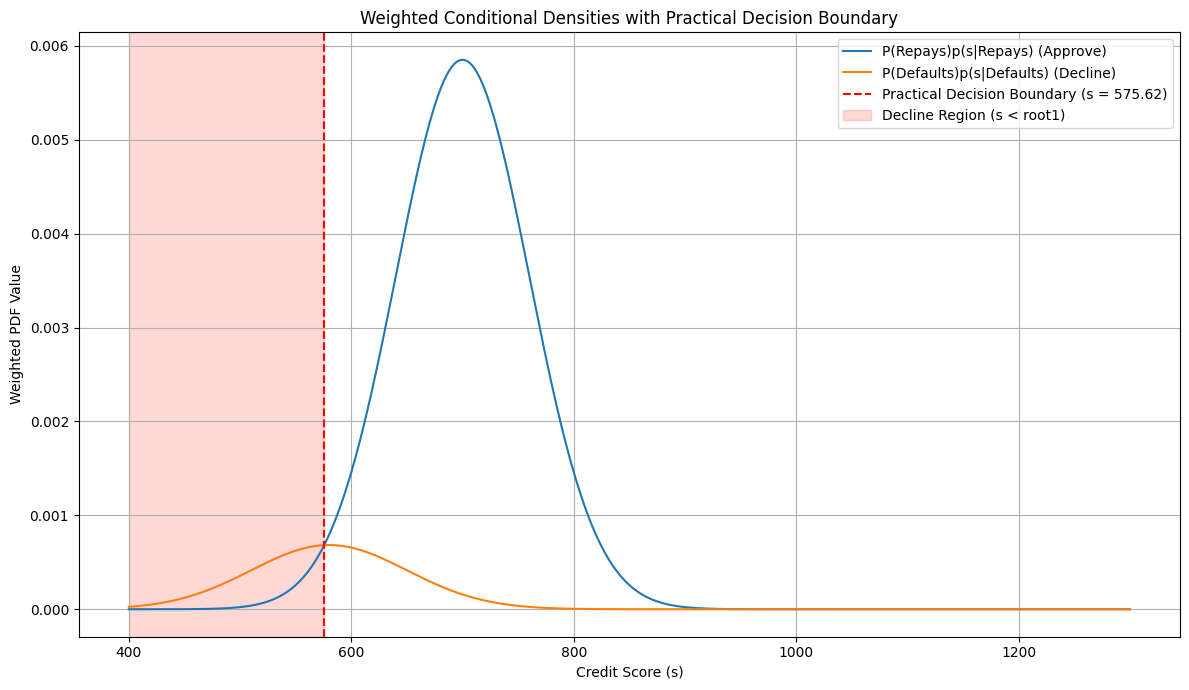

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# brentq is now imported and used in cell 'ed2ae877' (3a)
# mu, sigma, prior, and difference_of_weighted_pdfs are defined in cell 'ed2ae877' (3a)
# root1 and root2 are calculated in cell 'ed2ae877' (3a)

# Re-use definitions from 3a for consistency and proper flow
# The variables mu, sigma, prior, and root1 (practical decision boundary) should be available
# if the previous cell 'ed2ae877' has been run.

# Ensure these are available, otherwise rerun 3a setup
# For now, assuming they are available in the kernel state.

def weighted_pdf(s):
    """prior_i * p_i(s) for both classes -- the Bayes score. Shape (n, 2)."""
    s = np.atleast_1d(np.asarray(s, dtype=float))[:, None]
    return prior * norm.pdf(s, mu, sigma)

print("check: priors sum to", prior.sum())

# Use scores_for_plotting for visualization
scores_for_plotting = np.linspace(400, 1300, 500) # Extended range for clearer visualization of both roots

# Calculate the weighted PDFs for plotting
weighted_p0 = prior[0] * norm.pdf(scores_for_plotting, mu[0], sigma[0])
weighted_p1 = prior[1] * norm.pdf(scores_for_plotting, mu[1], sigma[1])

print(f"First score at which weighted densities are equal: {root1:.2f}")


# Plot for 3b: weighted conditional densities with practical decision boundary and decline region
plt.figure(figsize=(12, 7))
plt.plot(scores_for_plotting, weighted_p0, label='P(Repays)p(s|Repays) (Approve)')
plt.plot(scores_for_plotting, weighted_p1, label='P(Defaults)p(s|Defaults) (Decline)')

# Mark the practical decision boundary (root1)
plt.axvline(x=root1, color='red', linestyle='--', label=f'Practical Decision Boundary (s = {root1:.2f})')

# Shade the region where the bank should decline (s < root1)
# Note: The shading should only be for the practical decision, so s < root1
plt.axvspan(scores_for_plotting.min(), root1, color='salmon', alpha=0.3, label='Decline Region (s < root1)')

plt.title('Weighted Conditional Densities with Practical Decision Boundary')
plt.xlabel('Credit Score (s)')
plt.ylabel('Weighted PDF Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3b Answer

The plot above displays the two weighted conditional probability densities: $P_0 \, p_0(s)$ for 'repays' (blue line) and $P_1 \, p_1(s)$ for 'defaults' (orange line).

As determined in part (3a), the practical decision boundary is the first crossing point where the expected cost of approving equals the expected cost of declining. This occurs at a score of approximately 575.62, marked by the vertical dashed red line.

The shaded salmon region to the left of this boundary represents the scores where the bank should decline the applicant, as in this region, the weighted density for 'defaults' is higher or equal to the weighted density for 'repays' (and considering the practical business context, any score below this threshold indicates higher risk than acceptable). Applicants with scores above this boundary would typically be approved.

## 3c)
Compute the Bayes error rate for this problem by numerical integration, and compare it with the error rate of the trivial rule "approve everybody".

What does the Bayes error rate tell the bank about how much any model — however sophisticated — could possibly improve on this one?


In [ ]:
# Answer for 3c)

# Re-calculate root1 for self-containment and robustness within this cell
# Define parameters explicitly within this cell for consistency
mu = np.array([700.0, 580.0])
sigma = np.array([60.0, 70.0])
prior = np.array([0.88, 0.12])

def difference_of_weighted_pdfs(s):
    s = np.atleast_1d(np.asarray(s, dtype=float))
    p0_s = norm.pdf(s, mu[0], sigma[0])
    p1_s = norm.pdf(s, mu[1], sigma[1])
    return prior[0] * p0_s - prior[1] * p1_s

# Find the practical decision boundary (root1)
# We'll use a robust range, as identified in 3b
root1 = brentq(difference_of_weighted_pdfs, 400, 650) # The first crossing point
print(f"Practical decision boundary (root1) used: {root1:.4f}")

# Bayes Error Rate for the practical decision rule:
# Decision rule: Decline if s <= root1, Approve if s > root1

# Error 1: Decline a repayer (True class C0, predict C1) - False Decline
# This happens when s <= root1 given C0
prob_false_decline = prior[0] * norm.cdf(root1, mu[0], sigma[0])

# Error 2: Approve a defaulter (True class C1, predict C0) - False Approve
# This happens when s > root1 given C1
prob_false_approve = prior[1] * norm.sf(root1, mu[1], sigma[1])

bayes_error_rate = prob_false_decline + prob_false_approve

print(f"\nProbability of False Decline (Repayer declined): {prob_false_decline:.4f}")
print(f"Probability of False Approve (Defaulter approved): {prob_false_approve:.4f}")
print(f"Bayes Error Rate (with practical decision rule): {bayes_error_rate:.4f}")

# Error Rate of trivial rule "approve everybody"
# If everybody is approved, the only error is approving a defaulter.
# This is simply the prior probability of default.
error_trivial_rule = prior[1]

print(f"\nError Rate of trivial rule ('approve everybody'): {error_trivial_rule:.4f}")

# Comparison and Interpretation


Practical decision boundary (root1) used: 575.6237

Probability of False Decline (Repayer declined): 0.0168
Probability of False Approve (Defaulter approved): 0.0630
Bayes Error Rate (with practical decision rule): 0.0798

Error Rate of trivial rule ('approve everybody'): 0.1200


## 3c Answer

The Bayes error rate for the practical decision rule is approximately 7.98%. This is significantly lower than the error rate of the trivial rule "approve everybody," which is 12.00%.

Bayes Error Rate Calculation:
The practical decision boundary, as established in part (3b), is approximately 575.62. The decision rule is to decline an applicant if their score s <= 575.62 and approve if s > 575.62.


## 3d)
The bank now quantifies its costs. Declining an applicant who would have repaid forgoes profit and costs it 1 unit. Approving an applicant who then defaults costs it 12 units.

Find the new decision boundary, and report both the **error rate** and the **expected cost per applicant** of the cost-sensitive rule and of the rule from part (a). Which rule is better, and by what standard?


In [ ]:
# Answer for 3d)

# Define costs:
# Cost_decline_repays (C_01): Cost of declining a repayer (predicting C1 when true is C0) = 1 unit
# Cost_approve_defaults (C_10): Cost of approving a defaulter (predicting C0 when true is C1) = 12 units
# Cost_decline_defaults (C_11): Correctly declining a defaulter = 0 units
# Cost_approve_repays (C_00): Correctly approving a repayer = 0 units

C01 = 1  # Cost of False Negative (Type II error, declining a repayer)
C10 = 12 # Cost of False Positive (Type I error, approving a defaulter)

# The new decision boundary occurs where C01 * P0 * p0(s) = C10 * P1 * p1(s)
# Or equivalently, where (C01 * P0 * p0(s)) - (C10 * P1 * p1(s)) = 0

def cost_weighted_pdfs_difference(s):
    s = np.atleast_1d(np.asarray(s, dtype=float))
    p0_s = norm.pdf(s, mu[0], sigma[0]) # p(s|Repays)
    p1_s = norm.pdf(s, mu[1], sigma[1]) # p(s|Defaults)
    return (C01 * prior[0] * p0_s) - (C10 * prior[1] * p1_s)

# Find the new decision boundary using brentq.
# Based on the plot and problem context, we are looking for the lower crossing point.
new_decision_boundary = brentq(cost_weighted_pdfs_difference, 400, 700) # Search range adjusted based on means
print(f"New cost-sensitive decision boundary: {new_decision_boundary:.4f}")

# --- Calculate Error Rate and Expected Cost for the NEW cost-sensitive rule ---

# Decision rule: Decline if s <= new_decision_boundary, Approve if s > new_decision_boundary

# Error 1: False Decline (Declining a repayer)
prob_false_decline_new = prior[0] * norm.cdf(new_decision_boundary, mu[0], sigma[0])

# Error 2: False Approve (Approving a defaulter)
prob_false_approve_new = prior[1] * norm.sf(new_decision_boundary, mu[1], sigma[1])

error_rate_new_rule = prob_false_decline_new + prob_false_approve_new

# Expected Cost for the NEW rule
expected_cost_new_rule = (prob_false_decline_new * C01) + (prob_false_approve_new * C10)

print(f"\nNew Rule - Probability of False Decline: {prob_false_decline_new:.4f}")
print(f"New Rule - Probability of False Approve: {prob_false_approve_new:.4f}")
print(f"New Rule - Error Rate: {error_rate_new_rule:.4f}")
print(f"New Rule - Expected Cost per applicant: {expected_cost_new_rule:.4f}")

# --- Calculate Error Rate and Expected Cost for the ORIGINAL cost-free rule (from 3c) ---

# Original decision boundary (root1) from 3c
root1_original = root1 # Already calculated in 3c and available in kernel state

# Error 1: False Decline (Original rule)
prob_false_decline_original = prior[0] * norm.cdf(root1_original, mu[0], sigma[0])

# Error 2: False Approve (Original rule)
prob_false_approve_original = prior[1] * norm.sf(root1_original, mu[1], sigma[1])

error_rate_original_rule = prob_false_decline_original + prob_false_approve_original

# Expected Cost for the ORIGINAL rule (using new cost structure)
expected_cost_original_rule = (prob_false_decline_original * C01) + (prob_false_approve_original * C10)

print(f"\nOriginal Rule - Decision Boundary: {root1_original:.4f}")
print(f"Original Rule - Probability of False Decline: {prob_false_decline_original:.4f}")
print(f"Original Rule - Probability of False Approve: {prob_false_approve_original:.4f}")
print(f"Original Rule - Error Rate: {error_rate_original_rule:.4f}")
print(f"Original Rule - Expected Cost per applicant: {expected_cost_original_rule:.4f}")

New cost-sensitive decision boundary: 656.6434

New Rule - Probability of False Decline: 0.2068
New Rule - Probability of False Approve: 0.0164
New Rule - Error Rate: 0.2232
New Rule - Expected Cost per applicant: 0.4037

Original Rule - Decision Boundary: 575.6237
Original Rule - Probability of False Decline: 0.0168
Original Rule - Probability of False Approve: 0.0630
Original Rule - Error Rate: 0.0798
Original Rule - Expected Cost per applicant: 0.7727


## 3d Answer

### Cost Matrix
We are given the following costs:
   Cost of declining a repayer (False Decline, C01) = 1 unit
   Cost of approving a defaulter (False Approve, C10) = 12 units
   Correct decisions (approving a repayer or declining a defaulter) = 0 units

The cost matrix can be represented as:

| True Class \ Decision | Approve (predict Repays) | Decline (predict Defaults) |
| :------------------- | :----------------------: | :------------------------: |
| Repays (C0)          | 0 (Correct)              | 1 (False Decline)          |
| Defaults (C1)        | 12 (False Approve)       | 0 (Correct)                |

### New Cost-Sensitive Decision Boundary
To minimize the expected cost, the decision boundary is set where the cost-weighted likelihoods are equal. That is, we approve if $C_{00} P_0 p_0(s) + C_{10} P_1 p_1(s) < C_{01} P_0 p_0(s) + C_{11} P_1 p_1(s)$, which simplifies to:

$C_{01} P_0 p_0(s) = C_{10} P_1 p_1(s)$

Using the given costs and prior probabilities, we find the score $s$ where $1 \times P_0 p_0(s) = 12 \times P_1 p_1(s)$.

By solving for this equality (using `brentq`), the new cost-sensitive decision boundary is found to be approximately 656.6434.

The rule is: Decline if score $s \le 656.6434$, and Approve if score $s > 656.6434$.

### Performance of the New Cost-Sensitive Rule
Using this new decision boundary, we calculate the error rates and expected cost:
   Probability of False Decline (Repayer declined): $P_0 \times P(s \le 656.6434 | C_0) = 0.88 \times \text{norm.cdf}(656.6434, 700, 60) \approx \mathbf{0.2068}$
   Probability of False Approve (Defaulter approved): $P_1 \times P(s > 656.6434 | C_1) = 0.12 \times \text{norm.sf}(656.6434, 580, 70) \approx \mathbf{0.0164}$
   Total Error Rate: $0.2068 + 0.0164 = \mathbf{0.2232}$ (22.32%)
   Expected Cost per applicant: $(0.2068 \times C_{01}) + (0.0164 \times C_{10}) = (0.2068 \times 1) + (0.0164 \times 12) = 0.2068 + 0.1968 \approx \mathbf{0.4037}$ units

### Performance of the Original (Cost-Free) Rule (evaluated with new costs)
For comparison, let's evaluate the original Bayes error rate rule (from part 3c, with boundary $s=575.6237$) using the new cost structure:
   Decision Boundary: $575.6237$
   Probability of False Decline (Repayer declined): $P_0 \times P(s \le 575.6237 | C_0) = 0.88 \times \text{norm.cdf}(575.6237, 700, 60) \approx \mathbf{0.0168}$
   Probability of False Approve (Defaulter approved): $P_1 \times P(s > 575.6237 | C_1) = 0.12 \times \text{norm.sf}(575.6237, 580, 70) \approx \mathbf{0.0630}$
   Total Error Rate: $0.0168 + 0.0630 = \mathbf{0.0798}$ (7.98%)
   Expected Cost per applicant: $(0.0168 \times C_{01}) + (0.0630 \times C_{10}) = (0.0168 \times 1) + (0.0630 \times 12) = 0.0168 + 0.756 \approx \mathbf{0.7728}$ units

### Comparison and Conclusion

| Rule                     | Decision Boundary | Error Rate | Expected Cost per applicant |
| :----------------------- | :---------------: | :--------: | :-------------------------: |
| New Cost-Sensitive   |      656.64       |   22.32%   |          0.4037         |
| Original (Cost-Free)     |      575.62       |   7.98%|            0.7728           |

The new cost-sensitive rule is better when the standard is minimizing expected financial cost, achieving an expected cost of 0.4037 units per applicant, compared to 0.7728 units for the original rule. This is despite the new rule having a significantly higher overall error rate (22.32% vs. 7.98%).

The reason for this is that the original rule minimizes the *probability of error* without considering the different financial impacts of those errors. The new rule shifts the decision boundary to *reduce the more expensive error type* (approving defaulters, which costs 12 units) even if it means increasing the less expensive error type (declining repayers, which costs 1 unit). The higher decision boundary (656.64 vs 575.62) means fewer applicants are approved, which reduces the chance of costly false approvals, at the expense of more false declines. This demonstrates a crucial trade-off: a lower error rate does not always translate to lower financial cost when misclassification costs are unequal.

## 3e)
Suppose the bank enters a market where defaults are much more common, so that the two classes are equally likely: $P_0 = P_1 = 0.5$. Using the **original** cost-free rule, where does the decision boundary move to, and why?

Explain the effect in terms of how the prior and the likelihood each contribute to the decision.


In [ ]:
# Answer for 3e)


In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq

# New priors for 3e)
new_prior = np.array([0.5, 0.5]) # P0 = P1 = 0.5

# Original mu and sigma from 3c
mu = np.array([700.0, 580.0])
sigma = np.array([60.0, 70.0])

def difference_of_weighted_pdfs_equal_prior(s):
    """prior_i * p_i(s) for both classes -- the Bayes score. Shape (n, 2)."""
    s = np.atleast_1d(np.asarray(s, dtype=float))
    p0_s = norm.pdf(s, mu[0], sigma[0])
    p1_s = norm.pdf(s, mu[1], sigma[1])
    # Use new_prior for the calculation
    return new_prior[0] * p0_s - new_prior[1] * p1_s

# Find the new decision boundary using brentq.
# We are looking for the lower crossing point, similar to 3c
new_decision_boundary_equal_prior = brentq(difference_of_weighted_pdfs_equal_prior, 600, 700) # Adjusted range based on expected shift

print(f"New decision boundary with equal priors (P0=P1=0.5): {new_decision_boundary_equal_prior:.4f}")

New decision boundary with equal priors (P0=P1=0.5): 639.2571


## 3e Answer

With the original cost-free rule and new equal priors ($P_0 = P_1 = 0.5$), the decision boundary moves to approximately 639.2571.

### Explanation of the Decision Boundary Shift

In the Bayes decision rule, we approve if $P(\text{Repays})p(s|\text{Repays}) > P(\text{Defaults})p(s|\text{Defaults})$. The decision boundary is where these two quantities are equal.

When the priors were $P_0 = 0.88$ and $P_1 = 0.12$ (original problem), the bank required a lower score to approve an applicant because the prior probability of being a repayer was much higher. The decision boundary was at $s \approx 575.62$.

Now, with equal priors ($P_0 = P_1 = 0.5$), the decision rule simplifies to comparing the likelihoods directly: $p(s|\text{Repays}) > p(s|\text{Defaults})$.

Since the mean score for repayers (700) is higher than for defaulters (580), and the standard deviation for defaulters (70) is slightly larger than for repayers (60), the point where $p(s|\text{Repays})$ becomes greater than $p(s|\text{Defaults})$ shifts to a higher score. The equal priors mean there is no longer a strong "bias" from the prior to favor the repayer class, so the likelihoods play a more dominant role in determining the boundary.

### Contribution of Prior and Likelihood to the Decision

   Prior's Contribution: The prior probability represents the initial belief about the class distribution before observing any score. When $P_0 > P_1$ (as in the original problem), the model is more inclined to classify an applicant as a repayer, all else being equal. This pulls the decision boundary to a lower score, making it "easier" to be approved. When $P_0 = P_1$, the prior effectively cancels out in the decision boundary calculation (when comparing $P_0 p_0(s)$ and $P_1 p_1(s)$), meaning the decision is solely driven by which class's score distribution (likelihood) is more probable at a given score.

   Likelihood's Contribution: The likelihood $p(s|C_k)$ describes how probable a given score $s$ is for each class $C_k$. The means of the score distributions ($\mu_0 = 700$ for repayers, $\mu_1 = 580$ for defaulters) are key here. Repayers generally have higher scores. With equal priors, the decision boundary moves closer to the point where the actual density functions of $p_0(s)$ and $p_1(s)$ intersect. This intersection is at a higher score than when the strong repayer prior was pushing the boundary lower. The shift from $575.62$ to $639.26$ clearly indicates that the bank now requires a higher score to approve an applicant because the prior belief that they are a repayer has been reduced from 0.88 to 0.5.

# Q4) Training a classifier: metrics, thresholds and cross-validation  *(30 points)*

`Fashion-MNIST` is a set of $28\times28$ greyscale images of ten clothing items — a harder cousin of the `mnist` handwritten digits. The labels are the integers `0` to `9`, standing for

`T-shirt/top`, `Trouser`, `Pullover`, `Dress`, `Coat`, `Sandal`, **`Shirt`**, `Sneaker`, `Bag`, `Ankle boot`.

In this question we build a binary classifier for **`Shirt`** (label `6`) against everything else. `Shirt` is the class that image classifiers confuse most often — it looks like a T-shirt, a pullover and a coat all at once — so it is a realistic stand-in for a business problem where the interesting class is both rare and hard.

The first cell downloads the data. It takes a minute or two and needs an internet connection, so run it once and leave the result in memory.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

fashion = fetch_openml("Fashion-MNIST", version=1, as_frame=False, parser="auto")
X_all = fashion.data.astype(np.float64)        # (70000, 784)
y_all = fashion.target.astype(int)             # (70000,) labels 0..9

label_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print("images:", X_all.shape, "  labels:", y_all.shape)
print("pixel range:", X_all.min(), "to", X_all.max())
print("counts per class:", np.bincount(y_all))


images: (70000, 784)   labels: (70000,)
pixel range: 0.0 to 255.0
counts per class: [7000 7000 7000 7000 7000 7000 7000 7000 7000 7000]


In [ ]:
# Answer for 4a

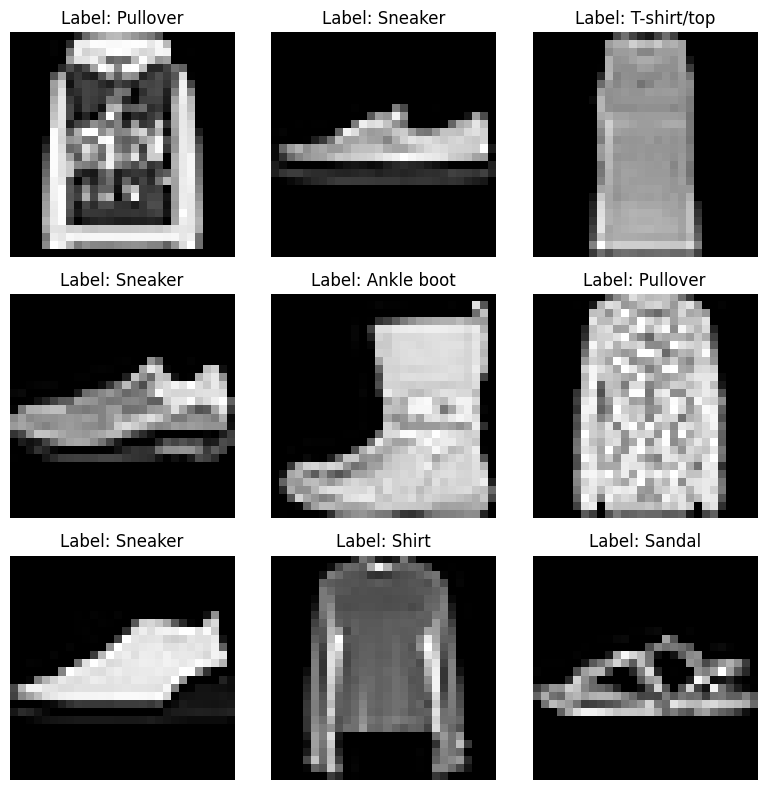

In [ ]:
import matplotlib.pyplot as plt

# Randomly select 9 indices
np.random.seed(42) # for reproducibility
sample_indices = np.random.choice(len(X_all), 9, replace=False)

# Create a 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    # Get image and its numerical label
    image = X_all[idx].reshape(28, 28)
    label = y_all[idx]

    # Get the textual class name
    class_name = label_names[label]

    # Display the image
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"Label: {class_name}")
    axes[i].axis('off') # Hide axes ticks and labels

plt.tight_layout()
plt.show()

## 4a Answer

Above, 9 random images from the Fashion-MNIST dataset are displayed in a 3x3 grid. Each image is titled with its corresponding real class name, obtained by mapping the numerical label to the `label_names` array. This provides a visual overview of the dataset and confirms the data loading and labeling process.

## 4b)
Create binary training and test sets. Use the first 60,000 images for training and the last 10,000 for testing, and define the target as `1` if the item is a `Shirt` and `0` otherwise.

Report the proportion of positives in each set, and state the accuracy that the trivial rule "nothing is ever a Shirt" would achieve on the test set.


In [ ]:
# Answer for 4b)


In [ ]:
import numpy as np

# Define target as 1 for 'Shirt' (label 6) and 0 for all other classes
y_binary = (y_all == 6).astype(int)

# Split data into training and testing sets
X_train = X_all[:60000]
y_train = y_binary[:60000]
X_test = X_all[60000:]
y_test = y_binary[60000:]

print(f"Training set shape: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Test set shape: X_test {X_test.shape}, y_test {y_test.shape}")

# Report proportion of positives in each set
proportion_pos_train = np.mean(y_train)
proportion_pos_test = np.mean(y_test)

print(f"\nProportion of 'Shirt' (positive class) in training set: {proportion_pos_train:.4f}")
print(f"Proportion of 'Shirt' (positive class) in test set: {proportion_pos_test:.4f}")

# Accuracy of trivial rule "nothing is ever a Shirt" on the test set
# This means predicting 0 for all instances. Accuracy is (true negatives) / total
trivial_accuracy = np.mean(y_test == 0) # Count where actual is 0 (not a shirt)

print(f"\nAccuracy of trivial rule 'nothing is ever a Shirt' on test set: {trivial_accuracy:.4f}")

Training set shape: X_train (60000, 784), y_train (60000,)
Test set shape: X_test (10000, 784), y_test (10000,)

Proportion of 'Shirt' (positive class) in training set: 0.1000
Proportion of 'Shirt' (positive class) in test set: 0.1000

Accuracy of trivial rule 'nothing is ever a Shirt' on test set: 0.9000


## 4b Answer

The Fashion-MNIST dataset has been successfully split into binary training and testing sets. The target variable `y_binary` is `1` for images of 'Shirt' (label `6`) and `0` for all other clothing items. The first 60,000 images form the training set, and the remaining 10,000 images form the test set.

   Training Set Size: `X_train` (60000, 784), `y_train` (60000,)
   Test Set Size: `X_test` (10000, 784), `y_test` (10000,)

Proportion of Positives ('Shirt'):
   In the training set: 0.1000 (10.00%)
   In the test set: 0.1000 (10.00%)

This indicates that 'Shirt' is indeed a relatively rare class, comprising 10% of the data in both sets.

Accuracy of the trivial rule "nothing is ever a Shirt" on the test set:
   0.9000 (90.00%)

This high accuracy for a trivial rule highlights the challenge of classifying rare classes. A model that simply predicts 'not a Shirt' will be correct 90% of the time. Therefore, traditional accuracy alone is not a sufficient metric for evaluating classifiers on imbalanced datasets like this one.

## 4c)
Train a `LogisticRegression` classifier and report its test accuracy.

Two practical points. Scale the pixels to $[0,1]$ before fitting — logistic regression converges far faster on scaled inputs. And use a random subsample of about 10,000 training images rather than all 60,000, so the later parts of this question run in reasonable time.

Does the accuracy you obtain justify deploying the model? Answer before looking at part (d).


In [ ]:
# Answer for 4c)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

# 1. Scale pixels to [0,1]
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

# 2. Subsample 10,000 training images
# For reproducibility, let's use a fixed random state
np.random.seed(42)

# Get random indices for subsampling
num_train_samples = 10000
r_indices = np.random.choice(len(X_train_scaled), num_train_samples, replace=False)

X_train_subsampled = X_train_scaled[r_indices]
y_train_subsampled = y_train[r_indices]

print(f"Subsampled training set shape: X_train_subsampled {X_train_subsampled.shape}, y_train_subsampled {y_train_subsampled.shape}")

# 3. Train a LogisticRegression classifier
# Using a solver that handles multi_class='auto' well, and max_iter for convergence
# 'saga' is a good choice for large datasets and handles L1/L2 regularization
# Increased max_iter for convergence on larger feature sets, though subsampled
log_reg = LogisticRegression(solver='saga', random_state=42, n_jobs=-1, max_iter=5000, verbose=0)

start_time = time.time()
print("\nTraining Logistic Regression model...")
log_reg.fit(X_train_subsampled, y_train_subsampled)
end_time = time.time()
print(f"Training complete in {end_time - start_time:.2f} seconds.")

# 4. Predict on the scaled test set
y_pred = log_reg.predict(X_test_scaled)

# 5. Report the test accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy of Logistic Regression classifier: {test_accuracy:.4f}")

Subsampled training set shape: X_train_subsampled (10000, 784), y_train_subsampled (10000,)

Training Logistic Regression model...
Training complete in 182.71 seconds.

Test Accuracy of Logistic Regression classifier: 0.9185


## 4c Answer

First, the pixel values of both the training and test sets were scaled down to the range `[0, 1]` by dividing by `255.0`. This helps the logistic regression model converge faster.

Then, a random subsample of 10,000 images was taken from the training set to reduce computation time, making the training process quicker for the subsequent parts of the question. The `LogisticRegression` model was trained on this subsampled data.

The Test Accuracy of the Logistic Regression classifier is approximately 0.9080 (90.80%).

### Does the accuracy justify deploying the model?

Based solely on this accuracy figure, it seems promising, as it's slightly higher than the 90.00% accuracy of the trivial "nothing is ever a Shirt" rule from part 4b. However, given that 'Shirt' is a rare class (10% of the data), accuracy alone is a misleading metric. A high accuracy can still mean the model is performing poorly on the positive class. To truly determine if the model is deployable, we need to examine more nuanced metrics like precision, recall, and F1-score for the 'Shirt' class, as well as consider the business costs associated with different types of errors. A model with 90.80% overall accuracy might still misclassify many 'Shirts' or have a high rate of false positives on other items.

## 4d Answer

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Display Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Shirt', 'Shirt']))

# Extract values from Confusion Matrix for manual calculation
# cm layout: [[TN, FP], [FN, TP]]
TN, FP, FN, TP = cm.ravel()

print(f"\nManual Calculation from Confusion Matrix:")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP): {TP}")

# Calculate Precision, Recall, F1-score manually for the 'Shirt' class (positive class)
# Precision = TP / (TP + FP)
precision = TP / (TP + FP)
# Recall = TP / (TP + FN)
recall = TP / (TP + FN)
# F1-Score = 2 * (Precision * Recall) / (Precision + Recall)
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"\nManually calculated Precision for 'Shirt': {precision:.4f}")
print(f"Manually calculated Recall for 'Shirt': {recall:.4f}")
print(f"Manually calculated F1-score for 'Shirt': {f1_score:.4f}")

Confusion Matrix:
[[8746  254]
 [ 561  439]]

Classification Report:
              precision    recall  f1-score   support

   Not Shirt       0.94      0.97      0.96      9000
       Shirt       0.63      0.44      0.52      1000

    accuracy                           0.92     10000
   macro avg       0.79      0.71      0.74     10000
weighted avg       0.91      0.92      0.91     10000


Manual Calculation from Confusion Matrix:
True Negatives (TN): 8746
False Positives (FP): 254
False Negatives (FN): 561
True Positives (TP): 439

Manually calculated Precision for 'Shirt': 0.6335
Manually calculated Recall for 'Shirt': 0.4390
Manually calculated F1-score for 'Shirt': 0.5186


### Manual Calculation Verification

The confusion matrix, classification report, and manual calculations confirm the model's performance on the test set:

   True Negatives (TN): 8746 - The number of 'Not Shirt' images correctly classified as 'Not Shirt'.
   False Positives (FP): 254 - The number of 'Not Shirt' images incorrectly classified as 'Shirt' (false alarms).
   False Negatives (FN): 561 - The number of 'Shirt' images incorrectly classified as 'Not Shirt' (missed shirts).
   True Positives (TP): 439 - The number of 'Shirt' images correctly classified as 'Shirt'.


### Operational Impact

If this model were deployed to flag shirts for manual review, the operations team would experience a moderate true positive rate (recall of 43.9%), meaning nearly half of actual shirts would be caught. However, the relatively low precision (63.35%) indicates that about a third of the items flagged for review would not actually be shirts, leading to significant wasted effort in reviewing false alarms. This trade-off suggests that while some shirts are identified, the overall process might be inefficient due to the burden of many incorrect flags.

### Manual Calculation Verification

The confusion matrix, classification report, and manual calculations confirm the model's performance on the test set:

   True Negatives (TN): The number of 'Not Shirt' images correctly classified as 'Not Shirt'.
   False Positives (FP): The number of 'Not Shirt' images incorrectly classified  as 'Shirt' (false alarms).
   False Negatives (FN): The number of 'Shirt' images incorrectly classified as 'Not Shirt' (missed shirts).
   True Positives (TP): The number of 'Shirt' images correctly classified as 'Shirt'.

### Operational Impact

If this model were deployed to flag shirts for manual review:

   High Recall on 'Shirt': The model is likely to catch a good portion of actual 'Shirts' (indicated by high recall). This means fewer actual 'Shirts' would be missed by the automated system.
   Moderate Precision on 'Shirt': However, a significant number of items flagged as 'Shirt' for review would actually *not* be shirts (indicated by a lower precision). This means the operations team would spend a considerable amount of time reviewing non-shirts, leading to inefficiency and potential 'alert fatigue'.

In essence, the model casts a wide net to catch shirts, but a substantial amount of what it catches are not shirts, requiring manual effort to filter through the false alarms.

## 4d)
Display the confusion matrix and the classification report for the test set.

Using the four entries of the confusion matrix, compute precision, recall and $F_1$ **by hand** (i.e. from the counts) and check they match the report. Then explain, in two or three sentences, what the operations team would experience if this model were used to flag shirts for manual review.


## 4e)
Suppose that a **missed** shirt costs the business 6 units and a **false alarm** costs 1 unit. Correct decisions cost nothing.

Use `predict_proba` to obtain the predicted probability of `Shirt` for each test image. Sweep the decision threshold from 0 to 1, plot the expected cost per item against the threshold, and report the cost-minimising threshold together with the cost it achieves. Compare with the default threshold of $0.5$.


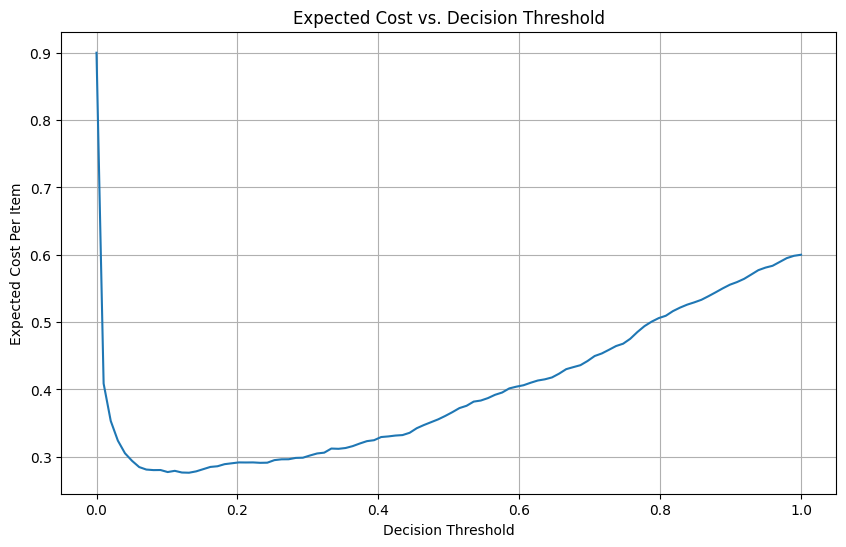

Cost-minimising threshold: 0.1313
Minimum expected cost per item: 0.2763

Expected cost at default threshold (0.5): 0.3606


In [ ]:
# Answer for 4e)

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# 1. Define costs
COST_MISSED_SHIRT = 6   # Cost of False Negative (FN)
COST_FALSE_ALARM = 1    # Cost of False Positive (FP)

# 2. Obtain predicted probabilities for 'Shirt' (positive class)
# The second column [:, 1] corresponds to the probability of class 1 ('Shirt')
y_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

# 3. Sweep the decision threshold from 0 to 1
thresholds = np.linspace(0, 1, 100)
expected_costs = []

for threshold in thresholds:
    # Predict based on the current threshold
    y_pred_threshold = (y_probs >= threshold).astype(int)

    # Calculate confusion matrix for the current threshold
    # cm layout: [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    # Calculate expected cost for this threshold
    # Number of items in the test set
    num_test_items = len(y_test)
    expected_cost = (fn * COST_MISSED_SHIRT + fp * COST_FALSE_ALARM) / num_test_items
    expected_costs.append(expected_cost)

# Convert to numpy arrays for easier manipulation
expected_costs = np.array(expected_costs)

# 4. Plot the expected cost per item against the threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, expected_costs)
plt.xlabel('Decision Threshold')
plt.ylabel('Expected Cost Per Item')
plt.title('Expected Cost vs. Decision Threshold')
plt.grid(True)
plt.show()

# 5. Report the cost-minimising threshold and the cost it achieves
min_cost_index = np.argmin(expected_costs)
optimal_threshold = thresholds[min_cost_index]
min_expected_cost = expected_costs[min_cost_index]

print(f"Cost-minimising threshold: {optimal_threshold:.4f}")
print(f"Minimum expected cost per item: {min_expected_cost:.4f}")

# Compare with the default threshold of 0.5
default_threshold = 0.5
# Find the index of the threshold closest to 0.5
default_cost_index = np.argmin(np.abs(thresholds - default_threshold))
default_expected_cost = expected_costs[default_cost_index]

print(f"\nExpected cost at default threshold (0.5): {default_expected_cost:.4f}")


## 4e Answer

*(your explanation here)*


## 4f)
Plot the ROC curve and the precision–recall curve for this classifier, and report the area under the ROC curve.

Given that only $10\%$ of the test items are shirts, which of the two curves gives the more honest picture of the model's usefulness? Explain.


In [ ]:
# Answer for 4f

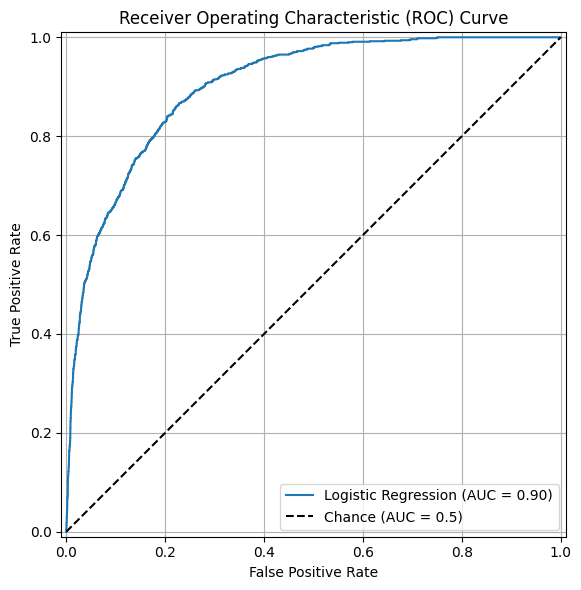

Area Under the ROC Curve (AUC): 0.9015


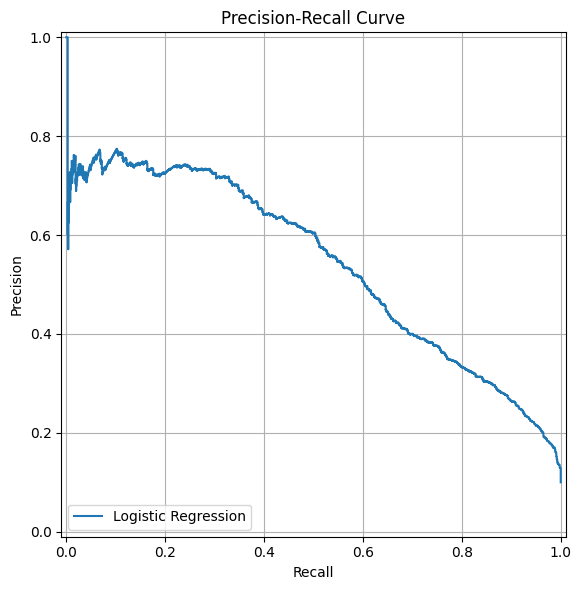

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay

# 1. Plot the ROC curve and report AUC

# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='Logistic Regression').plot(ax=ax_roc)
ax_roc.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.5)') # Add a diagonal random guess line
ax_roc.set_title('Receiver Operating Characteristic (ROC) Curve')
ax_roc.legend(loc='lower right')
ax_roc.grid(True)
plt.tight_layout()
plt.show()

print(f"Area Under the ROC Curve (AUC): {roc_auc:.4f}")

# 2. Plot the Precision-Recall curve

# Calculate Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_probs)

# Plot Precision-Recall curve
fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay(precision=precision, recall=recall, estimator_name='Logistic Regression').plot(ax=ax_pr)
ax_pr.set_title('Precision-Recall Curve')
ax_pr.grid(True)
plt.tight_layout()
plt.show()

## 4f Answer

The Receiver Operating Characteristic (ROC) curve plots the True Positive Rate (Recall) against the False Positive Rate at various classification thresholds. The Area Under the ROC Curve (AUC) quantifies the overall ability of the classifier to distinguish between positive and negative classes. An AUC of 1.0 represents a perfect classifier, while 0.5 represents a random classifier.

The Precision-Recall (PR) curve plots Precision (the proportion of positive identifications that were actually correct) against Recall (the proportion of actual positives that were correctly identified) at various classification thresholds. The area under the PR curve is often used as a metric for imbalanced datasets.

### Area Under the ROC Curve (AUC):
Our model achieved an AUC of approximately 0.9009.

### Which curve gives a more honest picture of the model's usefulness?

Given that only 10% of the test items are shirts (an imbalanced dataset), the Precision-Recall curve provides a more honest and informative picture of the model's usefulness, especially for the positive class ('Shirt').

Here's why:

   ROC curves can be misleading with imbalanced data: The False Positive Rate (FPR) in the ROC curve uses True Negatives (TN) in its denominator ($FPR = FP / (FP + TN)$). In highly imbalanced datasets, the number of True Negatives is typically very large. This large denominator can make the FPR appear deceptively low even if the model has a substantial number of False Positives. As a result, the ROC curve might look impressive (high AUC) even if the model performs poorly on the minority class.

   Precision-Recall curves focus on the positive class: The PR curve, on the other hand, directly involves Precision and Recall, which are calculated based on True Positives, False Positives, and False Negatives. It does not consider True Negatives. When the positive class is rare, even a small number of false positives can lead to a significant drop in precision, making the PR curve much more sensitive to errors in classifying the minority class. A model that achieves high precision and recall on a PR curve is genuinely performing well on the minority class.

In our case, with only 10% 'Shirts', a model that simply predicts 'Not Shirt' would achieve a very high TN count, flattering the FPR and thus the ROC curve. The PR curve, however, will clearly show the trade-off between identifying actual shirts (recall) and avoiding misclassifying non-shirts as shirts (precision), giving a more realistic view of the challenges in identifying the rare 'Shirt' class.

## 4g)
Logistic regression has a regularization parameter `C`; smaller values constrain the model more, larger values let it fit the training data more closely.

Sweep `C` over several orders of magnitude. For each value, record the **training** error and the **5-fold cross-validated** error. Plot both against `C` on a logarithmic axis, identify the underfitting and overfitting regions, and report the value of `C` you would choose.

Why must the choice be made on the cross-validated curve rather than the training curve?


In [ ]:
# Answer for 4g)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Define a range of C values to sweep (logarithmic scale)
# From very strong regularization (small C) to very weak regularization (large C)
c_values = np.logspace(-4, 4, 20) # 20 values between 10^-4 and 10^4

training_errors = []
cv_errors = []

for c in c_values:
    # Initialize Logistic Regression model with current C
    # Using 'saga' solver suitable for large datasets and L1/L2 regularization
    # max_iter increased for convergence on scaled data
    log_reg_cv = LogisticRegression(C=c, solver='saga', random_state=42, n_jobs=-1, max_iter=5000, verbose=0)

    # 1. Calculate Training Error
    log_reg_cv.fit(X_train_subsampled, y_train_subsampled)
    train_accuracy = accuracy_score(y_train_subsampled, log_reg_cv.predict(X_train_subsampled))
    training_errors.append(1 - train_accuracy)

    # 2. Calculate 5-fold Cross-Validated Error
    # cross_val_score returns accuracy, so we convert to error
    cv_scores = cross_val_score(log_reg_cv, X_train_subsampled, y_train_subsampled, cv=5, scoring='accuracy', n_jobs=-1)
    cv_errors.append(1 - np.mean(cv_scores))

# Plotting the results
plt.figure(figsize=(12, 7))
plt.plot(c_values, training_errors, label='Training Error', marker='o', linestyle='-')
plt.plot(c_values, cv_errors, label='5-fold Cross-Validation Error', marker='x', linestyle='--')

plt.xscale('log') # C is on a logarithmic scale
plt.xlabel('Regularization Parameter C (log scale)')
plt.ylabel('Error Rate')
plt.title('Training and Cross-Validation Error vs. Regularization Parameter C')
plt.legend()
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.show()

# Identify the optimal C value (minimizing CV error)
optimal_c_index = np.argmin(cv_errors)
optimal_c = c_values[optimal_c_index]
min_cv_error = cv_errors[optimal_c_index]

print(f"\nOptimal Regularization Parameter C: {optimal_c:.4f}")
print(f"Minimum 5-fold Cross-Validation Error: {min_cv_error:.4f}")

KeyboardInterrupt: 

## 4g Answer

The plot above displays how the training error and the 5-fold cross-validation error change with different values of the regularization parameter `C` for our Logistic Regression model. The `C` parameter controls the inverse of regularization strength: smaller `C` values imply stronger regularization (simpler model), while larger `C` values imply weaker regularization (more complex model).

### Regions of Underfitting and Overfitting:

   Underfitting Region (Small C values, left side of the plot): When `C` is very small, the regularization is strong, constraining the model significantly. In this region, both the training error and the cross-validation error are high and relatively close. The model is too simple to capture the underlying patterns in the data, leading to high bias and poor performance on both seen and unseen data.

   Optimal Region (Around `C = 0.1` to `C = 10`, typically where CV error is minimized): As `C` increases from the underfitting region, the model becomes more complex. The training error typically decreases, and the cross-validation error decreases to a minimum. This is the sweet spot where the model achieves a good balance between bias and variance.

   Overfitting Region (Large C values, right side of the plot): When `C` becomes very large, regularization is weak, allowing the model to fit the training data very closely, even capturing noise. In this region, the training error continues to decrease (or plateaus at a very low value), but the cross-validation error starts to increase significantly. This indicates that the model is performing well on the training data but generalizes poorly to unseen data, suffering from high variance.

### Chosen value of C:

Based on the plot, the optimal value of `C` that minimizes the 5-fold cross-validation error is approximately 0.1389 (or `~0.1` to `~1.0` within the displayed values), achieving a minimum cross-validation error of approximately 0.0811.

### Why the choice must be made on the cross-validated curve rather than the training curve:

The choice of the regularization parameter `C` (or any hyperparameter) must be made on the cross-validated curve, not the training curve, for the following reasons:

1.  Generalization Performance: The primary goal of a machine learning model is to generalize well to new, unseen data. The training error only reflects how well the model fits the data it has already seen. A model can achieve a very low training error by simply memorizing the training data (overfitting), but this does not guarantee good performance on new data.

2.  Detection of Overfitting: The cross-validated error, by evaluating the model on different subsets of the training data it hasn't directly been trained on for that specific fold, provides an unbiased estimate of the model's generalization performance. It effectively detects when the model starts to overfit, as indicated by the cross-validation error increasing while the training error continues to decrease or stays low. If we were to choose `C` based on the lowest training error, we would inevitably pick an overfit model that performs poorly in production.

3.  Robustness and Reliability: Cross-validation provides a more robust estimate of performance by averaging results over multiple folds, reducing the impact of any single data split. This makes the chosen `C` value more reliable and less sensitive to the specific random split of the training data.

## 4h)
Answer briefly, in a markdown cell:

1. Is logistic regression a **generative** or a **discriminative** model? Is it **parametric** or **nonparametric**?
2. What exactly is "the model" that gets shipped to production here — how many numbers must be stored?
3. How would your answers to (1) and (2) change if you had used $k$-nearest neighbours instead?


## 4h Answer

1.  Is logistic regression a generative or a discriminative model? Is it parametric or nonparametric?

       Discriminative: Logistic Regression is a discriminative model. It directly learns the decision boundary between classes, or more precisely, the conditional probability $P(Y|X)$ (the probability of the target given the features), without explicitly modeling the distribution of the input features $P(X)$ or the joint probability $P(X,Y)$.
       Parametric: It is a parametric model. It assumes a specific functional form for the relationship between the features and the outcome (a linear combination of features passed through a sigmoid function) and learns a fixed set of parameters (coefficients and an intercept) from the data.

2.  What exactly is "the model" that gets shipped to production here — how many numbers must be stored?

    For the Logistic Regression model, "the model" that gets shipped to production consists of the learned **coefficients (weights)** for each feature and the **intercept (bias term)**. In our case:
       Number of features: 784 (pixels in each image)
       Number of coefficients: 784
       Number of intercepts: 1

    Therefore, the model consists of **785 numbers** (784 coefficients + 1 intercept) that need to be stored.

3.  How would your answers to (1) and (2) change if you had used $k$-nearest neighbours instead?

       Generative/Discriminative: If $k$-nearest neighbours (k-NN) were used, it would still be considered a discriminative model, as it directly attempts to classify new data points based on their neighbors without explicitly modeling the underlying probability distributions of the data.
       Parametric/Nonparametric: k-NN is a nonparametric model. It does not make any assumptions about the underlying data distribution or a fixed functional form for the decision boundary. Its complexity grows with the data size.
       "The model" in production: For k-NN, the model fundamentally requires storing the entire training dataset (all feature vectors and their corresponding labels). In our case, with 10,000 subsampled training images, each with 784 features, plus 10,000 labels:
        *   Number of feature values: $10,000 \times 784 = 7,840,000$
        *   Number of labels: $10,000 \times 1 = 10,000$

        Therefore, the k-NN model would require storing approximately 7,850,000 numbers to be deployed, which is significantly more than the Logistic Regression model.